## Health Conditions and Healthcare Access Analysis

### Data Loading and Cleaning

#### Overview
This section covers the loading, cleaning, and preprocessing of three datasets 
used in the analysis of healthcare access and health conditions as determinants 
of life expectancy across U.S. counties. The datasets include:

- **PLACES: Local Data for Better Health** (CDC) — county-level health condition 
  prevalence estimates for 2019-2023
- **Health Insurance Coverage Characteristics** (U.S. Census Bureau ACS 5-year estimates) 
  — county-level uninsured rate breakdowns
- **County Health Rankings** — county-level life expectancy estimates for 2019-2023 
  (outcome variable)

Each dataset is cleaned and preprocessed independently before being merged into 
a single analytical dataset. Cleaning steps include removing descriptive header rows, 
standardizing column names, filtering to relevant variables and years, handling 
missing values, and reshaping data where necessary.

In [97]:
# Load required libraries
library(dplyr)
library(tidyr)
library(ggplot2)

options(warn = -1)

In [4]:
set.seed(100)

# Load data

# PLACES Health Dataset
health_data1 <- read.csv("PLACES__Local_Data_for_Better_Health__County_Data_2022_release.csv")
health_data2 <- read.csv("PLACES__Local_Data_for_Better_Health__County_Data_2023_release.csv")
health_data3 <- read.csv("PLACES__Local_Data_for_Better_Health__County_Data__2024_release.csv")

# Healthcare Coverage Dataset
healthcare_data <- read.csv("Healthcare_Coverage_2023_5-year_Data.csv")

# Life Expectancy (y-variable) Dataset
life_2019 <- read.csv("Life_Expectancy_Data_2019.csv")
life_2020 <- read.csv("Life_Expectancy_Data_2020.csv")
life_2021 <- read.csv("Life_Expectancy_Data_2021.csv")
life_2022 <- read.csv("Life_Expectancy_Data_2022.csv")
life_2023 <- read.csv("Life_Expectancy_Data_2023.csv")

### Health Conditions Data Cleaning

In [5]:
# Structure check

nrow(health_data1); ncol(health_data1)
nrow(health_data2); ncol(health_data2)
nrow(health_data3); ncol(health_data3)

colnames(health_data1)
colnames(health_data2)
colnames(health_data3)

head(health_data1)

[1] 188456

[1] 21

[1] 228770

[1] 21

[1] 229298

[1] 22

[1] "Year"                       "StateAbbr"                 
 [3] "StateDesc"                  "LocationName"              
 [5] "DataSource"                 "Category"                  
 [7] "Measure"                    "Data_Value_Unit"           
 [9] "Data_Value_Type"            "Data_Value"                
[11] "Data_Value_Footnote_Symbol" "Data_Value_Footnote"       
[13] "Low_Confidence_Limit"       "High_Confidence_Limit"     
[15] "TotalPopulation"            "LocationID"                
[17] "CategoryID"                 "MeasureId"                 
[19] "DataValueTypeID"            "Short_Question_Text"       
[21] "Geolocation"

[1] "Year"                       "StateAbbr"                 
 [3] "StateDesc"                  "LocationName"              
 [5] "DataSource"                 "Category"                  
 [7] "Measure"                    "Data_Value_Unit"           
 [9] "Data_Value_Type"            "Data_Value"                
[11] "Data_Value_Footnote_Symbol" "Data_Value_Footnote"       
[13] "Low_Confidence_Limit"       "High_Confidence_Limit"     
[15] "TotalPopulation"            "LocationID"                
[17] "CategoryID"                 "MeasureId"                 
[19] "DataValueTypeID"            "Short_Question_Text"       
[21] "Geolocation"

[1] "Year"                       "StateAbbr"                 
 [3] "StateDesc"                  "LocationName"              
 [5] "DataSource"                 "Category"                  
 [7] "Measure"                    "Data_Value_Unit"           
 [9] "Data_Value_Type"            "Data_Value"                
[11] "Data_Value_Footnote_Symbol" "Data_Value_Footnote"       
[13] "Low_Confidence_Limit"       "High_Confidence_Limit"     
[15] "TotalPopulation"            "TotalPop18plus"            
[17] "LocationID"                 "CategoryID"                
[19] "MeasureId"                  "DataValueTypeID"           
[21] "Short_Question_Text"        "Geolocation"

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,⋯,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<lgl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,2020,US,United States,,BRFSS,Prevention,Current lack of health insurance among adults aged 18-64 years,%,Crude prevalence,15.3,⋯,NA,15.0,15.7,331449281,59,PREVENT,ACCESS2,CrdPrv,Health Insurance,
2,2020,AL,Alabama,Talladega,BRFSS,Health Outcomes,Diagnosed diabetes among adults aged >=18 years,%,Crude prevalence,15.1,⋯,NA,14.3,15.9,79985,1121,HLTHOUT,DIABETES,CrdPrv,Diabetes,POINT (-86.1759302 33.3693135)
3,2020,AL,Alabama,Tallapoosa,BRFSS,Health Outcomes,Diagnosed diabetes among adults aged >=18 years,%,Crude prevalence,16.0,⋯,NA,15.0,17.0,40133,1123,HLTHOUT,DIABETES,CrdPrv,Diabetes,POINT (-85.7996176 32.8633076)
4,2020,AL,Alabama,Wilcox,BRFSS,Prevention,Visits to doctor for routine checkup within the past year among adults aged >=18 years,%,Age-adjusted prevalence,79.4,⋯,NA,78.4,80.4,10206,1131,PREVENT,CHECKUP,AgeAdjPrv,Annual Checkup,POINT (-87.3049349 31.9900824)
5,2020,AK,Alaska,Aleutians East,BRFSS,Prevention,Cervical cancer screening among adult women aged 21-65 years,%,Crude prevalence,68.3,⋯,NA,65.2,71.4,3401,2013,PREVENT,CERVICAL,CrdPrv,Cervical Cancer Screening,POINT (-161.9974772 55.2450437)
6,2020,AK,Alaska,Anchorage,BRFSS,Health Outcomes,Depression among adults aged >=18 years,%,Crude prevalence,16.5,⋯,NA,15.8,17.3,287095,2020,HLTHOUT,DEPRESSION,CrdPrv,Depression,POINT (-149.2843294 61.1742503)


In [6]:
# Stack all three PLACES files
health_data <- bind_rows(health_data1, health_data2, health_data3)

# Verify combined dataset
table(health_data$Year)
sum(is.na(health_data$Data_Value))
nrow(health_data)

health_data <- health_data %>% distinct()

# Verify years and duplicates are resolved
table(health_data$Year)
nrow(health_data)


  2019   2020   2021   2022   2023 
 24968 213792 178466  31450 197848 

[1] 66

[1] 646524


  2019   2020   2021   2022   2023 
 24968 213744 178466  31450 197848 

[1] 646476

#### Missing Value Check by Year

Before filtering, missing values are examined by year to identify gaps in health condition data. Several conditions are entirely absent for certain years; notably 2023 is missing Chronic Kidney Disease, Current Smoking, Mental Health, and Physical Health, while High Blood Pressure is missing for 2020.

The 5 conditions missing entire years are excluded from modeling by not selecting them in the model dataset. They remain in the merged dataset but are not used as predictors. The remaining 8 conditions are carried forward into modeling.

In [76]:
# Check missing values by year for health conditions
tapply(is.na(health_data$Data_Value), health_data$Year, sum)

# Check which years have data for each condition
table(health_data$Year, health_data$Short_Question_Text)

2019 2020 2021 2022 2023 
   0    0    0   10   56

      
       All Teeth Lost Annual Checkup Any Disability Arthritis Binge Drinking
  2019              0              0              0         0              0
  2020          12570           6288              0      6288           6288
  2021              0           6154           6154      6154           6154
  2022           6290              0              0         0              0
  2023              0           5916           5916      5916           5916
      
       Cancer (except skin) Cancer (non-skin) or Melanoma
  2019                    0                             0
  2020                 6288                             0
  2021                 6154                             0
  2022                    0                             0
  2023                    0                          5916
      
       Cervical Cancer Screening Cholesterol Screening Chronic Kidney Disease
  2019                         0                  6242                      0
  2020       

In [77]:
# Check how many years each condition has data for
colSums(table(health_data$Year, health_data$Short_Question_Text) > 0)

All Teeth Lost 
                                       2 
                          Annual Checkup 
                                       3 
                          Any Disability 
                                       2 
                               Arthritis 
                                       3 
                          Binge Drinking 
                                       3 
                    Cancer (except skin) 
                                       2 
           Cancer (non-skin) or Melanoma 
                                       1 
               Cervical Cancer Screening 
                                       1 
                   Cholesterol Screening 
                                       3 
                  Chronic Kidney Disease 
                                       2 
                    Cognitive Disability 
                                       2 
             Colorectal Cancer Screening 
                                       2 
                                    COPD 
                                       3 
  Core preventive services for older men 
                                       1 
Core preventive services for older women 
                                       1 
                  Coronary Heart Disease 
                                       3 
                          Current Asthma 
                                       3 
               Current Cigarette Smoking 
                                       1 
                         Current Smoking 
                                       2 
                            Dental Visit 
                                       2 
                              Depression 
                                       3 
                                Diabetes 
                                       3 
                         Food Insecurity 
                                       1 
                             Food Stamps 
                                       1 
                Frequent Mental Distress 
                                       1 
              Frequent Physical Distress 
                                       1 
                          General Health 
                                       3 
                        Health Insurance 
                                       3 
                      Hearing Disability 
                                       2 
                     High Blood Pressure 
                                       3 
          High Blood Pressure Medication 
                                       1 
                        High Cholesterol 
                                       3 
                      Housing Insecurity 
                                       1 
           Independent Living Disability 
                                       2 
        Lack of Social/Emotional Support 
                                       1 
                              Loneliness 
                                       1 
                             Mammography 
                                       2 
                           Mental Health 
                                       2 
                     Mobility Disability 
                                       2 
                                 Obesity 
                                       3 
                         Physical Health 
                                       2 
                     Physical Inactivity 
                                       3 
                    Self-care Disability 
                                       2 
                    Short Sleep Duration 
                                       1 
                          Sleep <7 hours 
                                       1 
                                  Stroke 
                                       3 
                    Taking BP Medication 
                                       2 
                 Transportation Barriers 
                                    

In [7]:
# Filter to conditions of interest, exclude 2019, handle age-adjusted/crude
conditions <- c("Obesity", "Diabetes", "Coronary Heart Disease",
                "High Blood Pressure", "COPD", "Current Smoking",
                "Physical Inactivity", "Mental Health", "Annual Checkup",
                "Depression", "Stroke", "Chronic Kidney Disease", 
                "Physical Health")

# Filter rows - exclude 2019, use age-adjusted for all years except 2022 (crude)
health_data <- health_data[
  health_data$Short_Question_Text %in% conditions &
  health_data$Year != 2019 &
  ((health_data$Year != 2022 & health_data$DataValueTypeID == "AgeAdjPrv") |
   (health_data$Year == 2022 & health_data$DataValueTypeID == "CrdPrv")), ]

# Drop NAs
health_data <- health_data[!is.na(health_data$Data_Value), ]

# Make Year categorical
health_data$Year <- as.factor(health_data$Year)

# Verify
table(health_data$Year)
table(health_data$Short_Question_Text)
nrow(health_data)


 2020  2021  2023 
37728 40001 26613 


        Annual Checkup Chronic Kidney Disease                   COPD 
                  9178                   6221                   9178 
Coronary Heart Disease        Current Smoking             Depression 
                  9178                   6221                   9178 
              Diabetes    High Blood Pressure          Mental Health 
                  9178                   6034                   6221 
               Obesity        Physical Health    Physical Inactivity 
                  9178                   6221                   9178 
                Stroke 
                  9178 

[1] 104342

#### Missing Value Handling Decision

Given that 2019 data is entirely absent for all 13 health condition variables, 
2019 observations are removed from the PLACES dataset prior to merging. This 
decision preserves the integrity of the health condition predictors without 
discarding 2019 life expectancy and uninsured rate data, which remain complete. 
As a result, health condition predictors are available for 2020-2023 only, while 
uninsured rate and life expectancy data span the full 2019-2023 period. During 
modeling, listwise deletion will be applied to retain only complete cases for 
the variables included in each model specification.

In [8]:
# Keep only necessary columns
health_data <- health_data[, c("LocationID", "LocationName", "StateAbbr", 
                                "Year", "Short_Question_Text", "Data_Value")]

# Verify
colnames(health_data)
nrow(health_data)
head(health_data)

[1] "LocationID"          "LocationName"        "StateAbbr"          
[4] "Year"                "Short_Question_Text" "Data_Value"

[1] 104342

,LocationID,LocationName,StateAbbr,Year,Short_Question_Text,Data_Value
,<int>,<chr>,<chr>,<fct>,<chr>,<dbl>
4,1131,Wilcox,AL,2020,Annual Checkup,79.4
9,2100,Haines,AK,2020,Stroke,2.9
14,2198,Prince of Wales-Hyder,AK,2020,COPD,7.4
26,5103,Ouachita,AR,2020,Current Smoking,24.4
30,6029,Kern,CA,2020,COPD,7.3
39,6097,Sonoma,CA,2020,Diabetes,8.2


In [9]:
# Rename columns
health_data <- health_data %>%
  rename(
    FIPS_Code = LocationID,
    County = LocationName,
    State = StateAbbr,
    Health_Condition = Short_Question_Text
  )

# Verify
colnames(health_data)
head(health_data)

[1] "FIPS_Code"        "County"           "State"            "Year"            
[5] "Health_Condition" "Data_Value"

,FIPS_Code,County,State,Year,Health_Condition,Data_Value
,<int>,<chr>,<chr>,<fct>,<chr>,<dbl>
4,1131,Wilcox,AL,2020,Annual Checkup,79.4
9,2100,Haines,AK,2020,Stroke,2.9
14,2198,Prince of Wales-Hyder,AK,2020,COPD,7.4
26,5103,Ouachita,AR,2020,Current Smoking,24.4
30,6029,Kern,CA,2020,COPD,7.3
39,6097,Sonoma,CA,2020,Diabetes,8.2


In [10]:
# Reshape to wide format
health_data <- health_data %>%
  pivot_wider(
    id_cols = c("FIPS_Code", "County", "State", "Year"),
    names_from = "Health_Condition",
    values_from = "Data_Value"
  )

# Verify
colnames(health_data)
nrow(health_data)
head(health_data)

[1] "FIPS_Code"              "County"                 "State"                 
 [4] "Year"                   "Annual Checkup"         "Stroke"                
 [7] "COPD"                   "Current Smoking"        "Diabetes"              
[10] "Depression"             "Coronary Heart Disease" "Obesity"               
[13] "Mental Health"          "Chronic Kidney Disease" "Physical Inactivity"   
[16] "Physical Health"        "High Blood Pressure"

[1] 9178

FIPS_Code,County,State,Year,Annual Checkup,Stroke,COPD,Current Smoking,Diabetes,Depression,Coronary Heart Disease,Obesity,Mental Health,Chronic Kidney Disease,Physical Inactivity,Physical Health,High Blood Pressure
<int>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1131,Wilcox,AL,2020,79.4,5.3,10.0,25.2,17.4,24.1,7.9,51.3,18.7,4.1,38.5,15.3,NA
2100,Haines,AK,2020,64.0,2.9,5.7,18.1,8.0,17.2,5.9,31.3,12.9,2.6,21.0,9.4,NA
2198,Prince of Wales-Hyder,AK,2020,62.9,3.9,7.4,24.5,11.0,18.1,7.4,34.2,14.9,3.2,25.8,12.1,NA
5103,Ouachita,AR,2020,77.3,4.1,8.9,24.4,13.6,23.7,7.4,40.4,17.8,3.5,36.4,14.4,NA
6029,Kern,CA,2020,68.0,3.4,7.3,15.1,12.5,18.3,6.6,35.0,16.4,3.3,28.1,12.9,NA
6097,Sonoma,CA,2020,63.2,2.4,5.3,11.8,8.2,17.7,5.0,25.2,14.2,2.5,18.5,9.1,NA


In [11]:
# Check how many NAs in each condition column
colSums(is.na(health_data))

# Check total rows
nrow(health_data)

FIPS_Code                 County                  State 
                     0                      0                      0 
                  Year         Annual Checkup                 Stroke 
                     0                      0                      0 
                  COPD        Current Smoking               Diabetes 
                     0                   2957                      0 
            Depression Coronary Heart Disease                Obesity 
                     0                      0                      0 
         Mental Health Chronic Kidney Disease    Physical Inactivity 
                  2957                   2957                      0 
       Physical Health    High Blood Pressure 
                  2957                   3144

[1] 9178

In [12]:
# Verify final clean dataset
summary(health_data)
nrow(health_data)
ncol(health_data)

   FIPS_Code        County             State             Year     
 Min.   :   59   Length:9178        Length:9178        2020:3144  
 1st Qu.:18176   Class :character   Class :character   2021:3077  
 Median :29215   Mode  :character   Mode  :character   2023:2957  
 Mean   :30530                                                    
 3rd Qu.:46031                                                    
 Max.   :56045                                                    
                                                                  
 Annual Checkup      Stroke           COPD        Current Smoking
 Min.   :54.70   Min.   :1.700   Min.   : 2.600   Min.   : 5.80  
 1st Qu.:70.90   1st Qu.:2.700   1st Qu.: 5.900   1st Qu.:16.90  
 Median :73.80   Median :3.000   Median : 6.900   Median :19.30  
 Mean   :73.29   Mean   :3.151   Mean   : 7.128   Mean   :19.52  
 3rd Qu.:76.30   3rd Qu.:3.400   3rd Qu.: 8.100   3rd Qu.:22.10  
 Max.   :84.00   Max.   :7.600   Max.   :16.500   Max.   :43.00  
  

[1] 9178

[1] 17

### Healthcare Access Data Cleaning

In [13]:
# Check structure
nrow(healthcare_data)
ncol(healthcare_data)
colnames(healthcare_data)
head(healthcare_data)

[1] 3223

[1] 613

[1] "GEO_ID"         "NAME"           "S2701_C01_001E" "S2701_C01_001M"
  [5] "S2701_C01_002E" "S2701_C01_002M" "S2701_C01_003E" "S2701_C01_003M"
  [9] "S2701_C01_004E" "S2701_C01_004M" "S2701_C01_005E" "S2701_C01_005M"
 [13] "S2701_C01_006E" "S2701_C01_006M" "S2701_C01_007E" "S2701_C01_007M"
 [17] "S2701_C01_008E" "S2701_C01_008M" "S2701_C01_009E" "S2701_C01_009M"
 [21] "S2701_C01_010E" "S2701_C01_010M" "S2701_C01_011E" "S2701_C01_011M"
 [25] "S2701_C01_012E" "S2701_C01_012M" "S2701_C01_013E" "S2701_C01_013M"
 [29] "S2701_C01_014E" "S2701_C01_014M" "S2701_C01_015E" "S2701_C01_015M"
 [33] "S2701_C01_016E" "S2701_C01_016M" "S2701_C01_017E" "S2701_C01_017M"
 [37] "S2701_C01_018E" "S2701_C01_018M" "S2701_C01_019E" "S2701_C01_019M"
 [41] "S2701_C01_020E" "S2701_C01_020M" "S2701_C01_021E" "S2701_C01_021M"
 [45] "S2701_C01_022E" "S2701_C01_022M" "S2701_C01_023E" "S2701_C01_023M"
 [49] "S2701_C01_024E" "S2701_C01_024M" "S2701_C01_025E" "S2701_C01_025M"
 [53] "S2701_C01_026E" "S2701_C01_026M" "S2701_C01_027E" "S2701_C01_027M"
 [57] "S2701_C01_028E" "S2701_C01_028M" "S2701_C01_029E" "S2701_C01_029M"
 [61] "S2701_C01_030E" "S2701_C01_030M" "S2701_C01_031E" "S2701_C01_031M"
 [65] "S2701_C01_032E" "S2701_C01_032M" "S2701_C01_033E" "S2701_C01_033M"
 [69] "S2701_C01_034E" "S2701_C01_034M" "S2701_C01_035E" "S2701_C01_035M"
 [73] "S2701_C01_036E" "S2701_C01_036M" "S2701_C01_037E" "S2701_C01_037M"
 [77] "S2701_C01_038E" "S2701_C01_038M" "S2701_C01_039E" "S2701_C01_039M"
 [81] "S2701_C01_040E" "S2701_C01_040M" "S2701_C01_041E" "S2701_C01_041M"
 [85] "S2701_C01_042E" "S2701_C01_042M" "S2701_C01_043E" "S2701_C01_043M"
 [89] "S2701_C01_044E" "S2701_C01_044M" "S2701_C01_045E" "S2701_C01_045M"
 [93] "S2701_C01_046E" "S2701_C01_046M" "S2701_C01_047E" "S2701_C01_047M"
 [97] "S2701_C01_048E" "S2701_C01_048M" "S2701_C01_049E" "S2701_C01_049M"
[101] "S2701_C01_050E" "S2701_C01_050M" "S2701_C01_051E" "S2701_C01_051M"
[105] "S2701_C01_052E" "S2701_C01_052M" "S2701_C01_053E" "S2701_C01_053M"
[109] "S2701_C01_054E" "S2701_C01_054M" "S2701_C01_055E" "S2701_C01_055M"
[113] "S2701_C01_056E" "S2701_C01_056M" "S2701_C01_057E" "S2701_C01_057M"
[117] "S2701_C01_058E" "S2701_C01_058M" "S2701_C01_059E" "S2701_C01_059M"
[121] "S2701_C01_060E" "S2701_C01_060M" "S2701_C01_061E" "S2701_C01_061M"
[125] "S2701_C02_001E" "S2701_C02_001M" "S2701_C02_002E" "S2701_C02_002M"
[129] "S2701_C02_003E" "S2701_C02_003M" "S2701_C02_004E" "S2701_C02_004M"
[133] "S2701_C02_005E" "S2701_C02_005M" "S2701_C02_006E" "S2701_C02_006M"
[137] "S2701_C02_007E" "S2701_C02_007M" "S2701_C02_008E" "S2701_C02_008M"
[141] "S2701_C02_009E" "S2701_C02_009M" "S2701_C02_010E" "S2701_C02_010M"
[145] "S2701_C02_011E" "S2701_C02_011M" "S2701_C02_012E" "S2701_C02_012M"
[149] "S2701_C02_013E" "S2701_C02_013M" "S2701_C02_014E" "S2701_C02_014M"
[153] "S2701_C02_015E" "S2701_C02_015M" "S2701_C02_016E" "S2701_C02_016M"
[157] "S2701_C02_017E" "S2701_C02_017M" "S2701_C02_018E" "S2701_C02_018M"
[161] "S2701_C02_019E" "S2701_C02_019M" "S2701_C02_020E" "S2701_C02_020M"
[165] "S2701_C02_021E" "S2701_C02_021M" "S2701_C02_022E" "S2701_C02_022M"
[169] "S2701_C02_023E" "S2701_C02_023M" "S2701_C02_024E" "S2701_C02_024M"
[173] "S2701_C02_025E" "S2701_C02_025M" "S2701_C02_026E" "S2701_C02_026M"
[177] "S2701_C02_027E" "S2701_C02_027M" "S2701_C02_028E" "S2701_C02_028M"
[181] "S2701_C02_029E" "S2701_C02_029M" "S2701_C02_030E" "S2701_C02_030M"
[185] "S2701_C02_031E" "S2701_C02_031M" "S2701_C02_032E" "S2701_C02_032M"
[189] "S2701_C02_033E" "S2701_C02_033M" "S2701_C02_034E" "S2701_C02_034M"
[193] "S2701_C02_035E" "S2701_C02_035M" "S2701_C02_036E" "S2701_C02_036M"
[197] "S2701_C02_037E" "S2701_C02_037M" "S2701_C02_038E" "S2701_C02_038M"
[201] "S2701_C02_039E" "S2701_C02_039M" "S2701_C02_040E" "S2701_C02_040M"
[205] "S2701_C02_041E" "S2701_C02_041M" "S2701_C02_042E" "S2701_C02_042M"
[209] "S2701_C02_043E" "S2701_C02_043M" "S2701_C02_044E" "S2701_C02_044M"
[213] "S2701_C02_045E" "S2701_C02_045M" "S2701_C02_046E" "S2701_C02_046M"
[217] 

,GEO_ID,NAME,S2701_C01_001E,S2701_C01_001M,S2701_C01_002E,S2701_C01_002M,S2701_C01_003E,S2701_C01_003M,S2701_C01_004E,S2701_C01_004M,⋯,S2701_C05_057M,S2701_C05_058E,S2701_C05_058M,S2701_C05_059E,S2701_C05_059M,S2701_C05_060E,S2701_C05_060M,S2701_C05_061E,S2701_C05_061M,X
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
1,Geography,Geographic Area Name,Estimate!!Total!!Civilian noninstitutionalized population,Margin of Error!!Total!!Civilian noninstitutionalized population,Estimate!!Total!!Civilian noninstitutionalized population!!AGE!!Under 6 years,Margin of Error!!Total!!Civilian noninstitutionalized population!!AGE!!Under 6 years,Estimate!!Total!!Civilian noninstitutionalized population!!AGE!!6 to 18 years,Margin of Error!!Total!!Civilian noninstitutionalized population!!AGE!!6 to 18 years,Estimate!!Total!!Civilian noninstitutionalized population!!AGE!!19 to 25 years,Margin of Error!!Total!!Civilian noninstitutionalized population!!AGE!!19 to 25 years,⋯,Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!RATIO OF INCOME TO POVERTY LEVEL IN THE PAST 12 MONTHS!!Civilian noninstitutionalized population for whom poverty status is determined,Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!RATIO OF INCOME TO POVERTY LEVEL IN THE PAST 12 MONTHS!!Civilian noninstitutionalized population for whom poverty status is determined!!Below 138 percent of the poverty threshold,Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!RATIO OF INCOME TO POVERTY LEVEL IN THE PAST 12 MONTHS!!Civilian noninstitutionalized population for whom poverty status is determined!!Below 138 percent of the poverty threshold,Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!RATIO OF INCOME TO POVERTY LEVEL IN THE PAST 12 MONTHS!!Civilian noninstitutionalized population for whom poverty status is determined!!138 to 399 percent of the poverty threshold,Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!RATIO OF INCOME TO POVERTY LEVEL IN THE PAST 12 MONTHS!!Civilian noninstitutionalized population for whom poverty status is determined!!138 to 399 percent of the poverty threshold,Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!RATIO OF INCOME TO POVERTY LEVEL IN THE PAST 12 MONTHS!!Civilian noninstitutionalized population for whom poverty status is determined!!At or above 400 percent of the poverty threshold,Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!RATIO OF INCOME TO POVERTY LEVEL IN THE PAST 12 MONTHS!!Civilian noninstitutionalized population for whom poverty status is determined!!At or above 400 percent of the poverty threshold,Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!RATIO OF INCOME TO POVERTY LEVEL IN THE PAST 12 MONTHS!!Civilian noninstitutionalized population for whom poverty status is determined!!Below 100 percent of the poverty threshold,Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!RATIO OF INCOME TO POVERTY LEVEL IN THE PAST 12 MONTHS!!Civilian noninstitutionalized population for whom poverty status is determined!!Below 100 percent of the poverty threshold,NA
2,0500000US01001,"Autauga County, Alabama",57953,269,4071,190,10561,247,4556,356,⋯,1.2,19.1,4.3,6.9,1.7,2.0,1.3,19.5,5.8,NA
3,0500000US01003,"Baldwin County, Alabama",236704,281,15617,531,37725,695,17263,738,⋯,0.8,17.2,2.3,9.0,1.4,3.9,0.9,19.9,2.9,NA
4,0500000US01005,"Barbour County, Alabama",21685,96,1665,164,3743,190,1730,134,⋯,2.3,16.8,4.9,9.6,2.7,5.0,2.9,20.1,6.1,NA
5,0500000US01007,"Bibb County, Alabama",20781,273,1301,162,3310,188,1794,255,⋯,2.2,16.3,5.5,7.0,2.4,2.2,2.0,13.4,5.2,NA
6,0500000US01009,"Blount County, Alabama",58829,18,4018,186,10269,283,5105,299,⋯,1.2,17.4,3.6,11.6,1.8,2.1,1.0,18.8,4.8,NA


In [14]:
# See all C05 columns (uninsured percent)
colnames(healthcare_data)[grep("C05", colnames(healthcare_data))]

# Check what the first row says for C05 columns
as.character(healthcare_data[1, grep("C05", colnames(healthcare_data))])

[1] "S2701_C05_001E" "S2701_C05_001M" "S2701_C05_002E" "S2701_C05_002M"
  [5] "S2701_C05_003E" "S2701_C05_003M" "S2701_C05_004E" "S2701_C05_004M"
  [9] "S2701_C05_005E" "S2701_C05_005M" "S2701_C05_006E" "S2701_C05_006M"
 [13] "S2701_C05_007E" "S2701_C05_007M" "S2701_C05_008E" "S2701_C05_008M"
 [17] "S2701_C05_009E" "S2701_C05_009M" "S2701_C05_010E" "S2701_C05_010M"
 [21] "S2701_C05_011E" "S2701_C05_011M" "S2701_C05_012E" "S2701_C05_012M"
 [25] "S2701_C05_013E" "S2701_C05_013M" "S2701_C05_014E" "S2701_C05_014M"
 [29] "S2701_C05_015E" "S2701_C05_015M" "S2701_C05_016E" "S2701_C05_016M"
 [33] "S2701_C05_017E" "S2701_C05_017M" "S2701_C05_018E" "S2701_C05_018M"
 [37] "S2701_C05_019E" "S2701_C05_019M" "S2701_C05_020E" "S2701_C05_020M"
 [41] "S2701_C05_021E" "S2701_C05_021M" "S2701_C05_022E" "S2701_C05_022M"
 [45] "S2701_C05_023E" "S2701_C05_023M" "S2701_C05_024E" "S2701_C05_024M"
 [49] "S2701_C05_025E" "S2701_C05_025M" "S2701_C05_026E" "S2701_C05_026M"
 [53] "S2701_C05_027E" "S2701_C05_027M" "S2701_C05_028E" "S2701_C05_028M"
 [57] "S2701_C05_029E" "S2701_C05_029M" "S2701_C05_030E" "S2701_C05_030M"
 [61] "S2701_C05_031E" "S2701_C05_031M" "S2701_C05_032E" "S2701_C05_032M"
 [65] "S2701_C05_033E" "S2701_C05_033M" "S2701_C05_034E" "S2701_C05_034M"
 [69] "S2701_C05_035E" "S2701_C05_035M" "S2701_C05_036E" "S2701_C05_036M"
 [73] "S2701_C05_037E" "S2701_C05_037M" "S2701_C05_038E" "S2701_C05_038M"
 [77] "S2701_C05_039E" "S2701_C05_039M" "S2701_C05_040E" "S2701_C05_040M"
 [81] "S2701_C05_041E" "S2701_C05_041M" "S2701_C05_042E" "S2701_C05_042M"
 [85] "S2701_C05_043E" "S2701_C05_043M" "S2701_C05_044E" "S2701_C05_044M"
 [89] "S2701_C05_045E" "S2701_C05_045M" "S2701_C05_046E" "S2701_C05_046M"
 [93] "S2701_C05_047E" "S2701_C05_047M" "S2701_C05_048E" "S2701_C05_048M"
 [97] "S2701_C05_049E" "S2701_C05_049M" "S2701_C05_050E" "S2701_C05_050M"
[101] "S2701_C05_051E" "S2701_C05_051M" "S2701_C05_052E" "S2701_C05_052M"
[105] "S2701_C05_053E" "S2701_C05_053M" "S2701_C05_054E" "S2701_C05_054M"
[109] "S2701_C05_055E" "S2701_C05_055M" "S2701_C05_056E" "S2701_C05_056M"
[113] "S2701_C05_057E" "S2701_C05_057M" "S2701_C05_058E" "S2701_C05_058M"
[117] "S2701_C05_059E" "S2701_C05_059M" "S2701_C05_060E" "S2701_C05_060M"
[121] "S2701_C05_061E" "S2701_C05_061M"

[1] "Estimate!!Percent Uninsured!!Civilian noninstitutionalized population"                                                                                                                                                                                                 
  [2] "Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population"                                                                                                                                                                                          
  [3] "Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!Under 6 years"                                                                                                                                                                             
  [4] "Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!Under 6 years"                                                                                                                                                                      
  [5] "Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!6 to 18 years"                                                                                                                                                                             
  [6] "Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!6 to 18 years"                                                                                                                                                                      
  [7] "Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!19 to 25 years"                                                                                                                                                                            
  [8] "Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!19 to 25 years"                                                                                                                                                                     
  [9] "Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!26 to 34 years"                                                                                                                                                                            
 [10] "Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!26 to 34 years"                                                                                                                                                                     
 [11] "Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!35 to 44 years"                                                                                                                                                                            
 [12] "Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!35 to 44 years"                                                                                                                                                                     
 [13] "Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!45 to 54 years"                                                                                                                                                                            
 [14] "Margin of Error!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!45 to 54 years"                                                                                                                                                                     
 [15] "Estimate!!Percent Uninsured!!Civilian noninstitutionalized population!!AGE!!55 to 64 years"                                                                                                              

In [15]:
# Remove descriptive header row
healthcare_data <- healthcare_data[-1, ]

# Verify first row is now actual data
head(healthcare_data[, 1:5])

,GEO_ID,NAME,S2701_C01_001E,S2701_C01_001M,S2701_C01_002E
,<chr>,<chr>,<chr>,<chr>,<chr>
2,0500000US01001,"Autauga County, Alabama",57953,269,4071
3,0500000US01003,"Baldwin County, Alabama",236704,281,15617
4,0500000US01005,"Barbour County, Alabama",21685,96,1665
5,0500000US01007,"Bibb County, Alabama",20781,273,1301
6,0500000US01009,"Blount County, Alabama",58829,18,4018
7,0500000US01011,"Bullock County, Alabama",9156,66,883


In [16]:
# Extract FIPS code from GEO_ID
healthcare_data$FIPS_Code <- substr(healthcare_data$GEO_ID, 10, 14)

# Verify it looks right
head(healthcare_data$FIPS_Code)

[1] "01001" "01003" "01005" "01007" "01009" "01011"

In [17]:
# Keep only FIPS, NAME and selected C05 estimate columns
keep_cols <- c("FIPS_Code", "NAME",
               "S2701_C05_001E",  # Uninsured_Total
               "S2701_C05_011E",  # Uninsured_Under19
               "S2701_C05_012E",  # Uninsured_19to64
               "S2701_C05_013E",  # Uninsured_65plus
               "S2701_C05_061E")  # Uninsured_Below100Pov

healthcare_data <- healthcare_data[, keep_cols]

# Verify
ncol(healthcare_data)
nrow(healthcare_data)
head(healthcare_data)

[1] 7

[1] 3222

,FIPS_Code,NAME,S2701_C05_001E,S2701_C05_011E,S2701_C05_012E,S2701_C05_013E,S2701_C05_061E
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2,01001,"Autauga County, Alabama",7.4,2.7,11.3,0.3,19.5
3,01003,"Baldwin County, Alabama",8.2,4.9,12.2,1.0,19.9
4,01005,"Barbour County, Alabama",10.8,4.7,18.0,0.0,20.1
5,01007,"Bibb County, Alabama",8.3,1.5,13.2,0.0,13.4
6,01009,"Blount County, Alabama",10.2,2.2,16.8,0.0,18.8
7,01011,"Bullock County, Alabama",12.9,1.3,22.7,0.0,10.6


63 columns (FIPS + NAME + 61 C05 estimates) and 3,222 rows (one per county). Looks great!

In [18]:
# Rename columns
healthcare_data <- healthcare_data %>%
  rename(
    County = NAME,
    Uninsured_Total = S2701_C05_001E,
    Uninsured_Under19 = S2701_C05_011E,
    Uninsured_19to64 = S2701_C05_012E,
    Uninsured_65plus = S2701_C05_013E,
    Uninsured_Below100Pov = S2701_C05_061E
  )

# Verify
colnames(healthcare_data)

[1] "FIPS_Code"             "County"                "Uninsured_Total"      
[4] "Uninsured_Under19"     "Uninsured_19to64"      "Uninsured_65plus"     
[7] "Uninsured_Below100Pov"

In [19]:
# Convert uninsured columns to numeric
healthcare_data <- healthcare_data %>%
  mutate(across(Uninsured_Total:Uninsured_Below100Pov, as.numeric))

# Verify
str(healthcare_data)

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `across(Uninsured_Total:Uninsured_Below100Pov, as.numeric)`.
Caused by warning:
! NAs introduced by coercion”


'data.frame':	3222 obs. of  7 variables:
 $ FIPS_Code            : chr  "01001" "01003" "01005" "01007" ...
 $ County               : chr  "Autauga County, Alabama" "Baldwin County, Alabama" "Barbour County, Alabama" "Bibb County, Alabama" ...
 $ Uninsured_Total      : num  7.4 8.2 10.8 8.3 10.2 12.9 12.3 11.1 12.2 9 ...
 $ Uninsured_Under19    : num  2.7 4.9 4.7 1.5 2.2 1.3 6.2 3.4 4.6 1.4 ...
 $ Uninsured_19to64     : num  11.3 12.2 18 13.2 16.8 22.7 19.2 17.4 18.8 15.2 ...
 $ Uninsured_65plus     : num  0.3 1 0 0 0 0 0.6 0.4 0.9 0.6 ...
 $ Uninsured_Below100Pov: num  19.5 19.9 20.1 13.4 18.8 10.6 19.9 20.6 17.1 19.4 ...


In [20]:
# Check NAs and verify final dataset
colSums(is.na(healthcare_data))
nrow(healthcare_data)
ncol(healthcare_data)
summary(healthcare_data)

FIPS_Code                County       Uninsured_Total 
                    0                     0                     0 
    Uninsured_Under19      Uninsured_19to64      Uninsured_65plus 
                    2                     0                     0 
Uninsured_Below100Pov 
                    0

[1] 3222

[1] 7

  FIPS_Code            County          Uninsured_Total  Uninsured_Under19
 Length:3222        Length:3222        Min.   : 0.000   Min.   : 0.000   
 Class :character   Class :character   1st Qu.: 5.600   1st Qu.: 2.800   
 Mode  :character   Mode  :character   Median : 8.000   Median : 4.700   
                                       Mean   : 9.154   Mean   : 6.186   
                                       3rd Qu.:11.500   3rd Qu.: 7.900   
                                       Max.   :44.300   Max.   :59.600   
                                                        NA's   :2        
 Uninsured_19to64 Uninsured_65plus  Uninsured_Below100Pov
 Min.   : 0.00    Min.   : 0.0000   Min.   : 0.00        
 1st Qu.: 8.20    1st Qu.: 0.0000   1st Qu.: 8.20        
 Median :11.70    Median : 0.3000   Median :12.90        
 Mean   :13.45    Mean   : 0.5581   Mean   :14.68        
 3rd Qu.:17.30    3rd Qu.: 0.7000   3rd Qu.:19.90        
 Max.   :59.00    Max.   :13.0000   Max.   :72.80        
  

### Life Expectancy Data Cleaning

In [21]:
# Structure check
nrow(life_2019); ncol(life_2019)
nrow(life_2020); ncol(life_2020)
nrow(life_2021); ncol(life_2021)
nrow(life_2022); ncol(life_2022)
nrow(life_2023); ncol(life_2023)

head(life_2019[, 1:6])

[1] 3195

[1] 534

[1] 3195

[1] 786

[1] 3195

...

[1] 3195

[1] 725

[1] 3195

[1] 720

,State.FIPS.Code,County.FIPS.Code,X5.digit.FIPS.Code,State.Abbreviation,Name,Release.Year
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,statecode,countycode,fipscode,state,county,year
2,00,000,00000,US,United States,2019
3,01,000,01000,AL,Alabama,2019
4,01,001,01001,AL,Autauga County,2019
5,01,003,01003,AL,Baldwin County,2019
6,01,005,01005,AL,Barbour County,2019


In [22]:
# Reload raw files, standardize column names to lowercase
life_2019 <- read.csv("Life_Expectancy_Data_2019.csv")
life_2020 <- read.csv("Life_Expectancy_Data_2020.csv")
life_2021 <- read.csv("Life_Expectancy_Data_2021.csv")
life_2022 <- read.csv("Life_Expectancy_Data_2022.csv")
life_2023 <- read.csv("Life_Expectancy_Data_2023.csv")

colnames(life_2019) <- tolower(colnames(life_2019))
colnames(life_2020) <- tolower(colnames(life_2020))
colnames(life_2021) <- tolower(colnames(life_2021))
colnames(life_2022) <- tolower(colnames(life_2022))
colnames(life_2023) <- tolower(colnames(life_2023))

# Step 3: Remove descriptive header row
life_2019 <- life_2019[-1, ]
life_2020 <- life_2020[-1, ]
life_2021 <- life_2021[-1, ]
life_2022 <- life_2022[-1, ]
life_2023 <- life_2023[-1, ]

# Verify
head(life_2019[, 1:6])

,state.fips.code,county.fips.code,x5.digit.fips.code,state.abbreviation,name,release.year
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2,00,000,00000,US,United States,2019
3,01,000,01000,AL,Alabama,2019
4,01,001,01001,AL,Autauga County,2019
5,01,003,01003,AL,Baldwin County,2019
6,01,005,01005,AL,Barbour County,2019
7,01,007,01007,AL,Bibb County,2019


In [23]:
# Stack all 5 files
life_exp <- bind_rows(life_2019, life_2020, life_2021, life_2022, life_2023)

# Verify combined dataset
table(life_exp$release.year)
nrow(life_exp)
sum(is.na(life_exp$life.expectancy.raw.value))


2019 2020 2021 2022 2023 
3194 3194 3194 3194 3194 

[1] 15970

[1] 0

In [24]:
# Keep only relevant columns
life_exp <- life_exp[, c("x5.digit.fips.code",
                          "name",
                          "release.year",
                          "life.expectancy.raw.value",
                          "population.raw.value",
                          "x..rural.raw.value")]
# Verify
colnames(life_exp)
nrow(life_exp)
head(life_exp)

[1] "x5.digit.fips.code"        "name"                     
[3] "release.year"              "life.expectancy.raw.value"
[5] "population.raw.value"      "x..rural.raw.value"

[1] 15970

,x5.digit.fips.code,name,release.year,life.expectancy.raw.value,population.raw.value,x..rural.raw.value
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,00000,United States,2019,79.063850411,325719178,
2,01000,Alabama,2019,75.41303499,4874747,0.409631829
3,01001,Autauga County,2019,76.330589011,55504,0.4200216232
4,01003,Baldwin County,2019,78.599497656,212628,0.4227909911
5,01005,Barbour County,2019,75.77945737,25270,0.677896347
6,01007,Bibb County,2019,73.928271076,22668,0.6835260746


In [25]:
# Rename columns
life_exp <- life_exp %>%
  rename(
    FIPS_Code = x5.digit.fips.code,
    County = name,
    Year = release.year,
    Life_Expectancy = life.expectancy.raw.value,
    Total_Population = population.raw.value,
    Pct_Rural = x..rural.raw.value
  )

# Verify
colnames(life_exp)
head(life_exp)

[1] "FIPS_Code"        "County"           "Year"             "Life_Expectancy" 
[5] "Total_Population" "Pct_Rural"

,FIPS_Code,County,Year,Life_Expectancy,Total_Population,Pct_Rural
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,00000,United States,2019,79.063850411,325719178,
2,01000,Alabama,2019,75.41303499,4874747,0.409631829
3,01001,Autauga County,2019,76.330589011,55504,0.4200216232
4,01003,Baldwin County,2019,78.599497656,212628,0.4227909911
5,01005,Barbour County,2019,75.77945737,25270,0.677896347
6,01007,Bibb County,2019,73.928271076,22668,0.6835260746


In [27]:
# Convert to numeric
life_exp <- life_exp %>%
  mutate(across(Life_Expectancy:Pct_Rural, as.numeric))

# Verify
str(life_exp)

# Make Year categorical
life_exp$Year <- as.factor(life_exp$Year)

'data.frame':	15970 obs. of  6 variables:
 $ FIPS_Code       : chr  "00000" "01000" "01001" "01003" ...
 $ County          : chr  "United States" "Alabama" "Autauga County" "Baldwin County" ...
 $ Year            : Factor w/ 5 levels "2019","2020",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Life_Expectancy : num  79.1 75.4 76.3 78.6 75.8 ...
 $ Total_Population: num  3.26e+08 4.87e+06 5.55e+04 2.13e+05 2.53e+04 ...
 $ Pct_Rural       : num  NA 0.41 0.42 0.423 0.678 ...


In [28]:
# Remove state/national rows and missing Life_Expectancy
life_exp <- life_exp[!grepl("000$", life_exp$FIPS_Code), ]
life_exp <- life_exp[!is.na(life_exp$Life_Expectancy), ]

# Verify
nrow(life_exp)
colSums(is.na(life_exp))
table(life_exp$Year)

[1] 15359

FIPS_Code           County             Year  Life_Expectancy 
               0                0                0                0 
Total_Population        Pct_Rural 
               0               30


2019 2020 2021 2022 2023 
3073 3069 3073 3072 3072 

In [29]:
# Final check of life_exp dataset
nrow(life_exp)
ncol(life_exp)
colnames(life_exp)
table(life_exp$Year)
colSums(is.na(life_exp))
summary(life_exp)

[1] 15359

[1] 6

[1] "FIPS_Code"        "County"           "Year"             "Life_Expectancy" 
[5] "Total_Population" "Pct_Rural"


2019 2020 2021 2022 2023 
3073 3069 3073 3072 3072 

FIPS_Code           County             Year  Life_Expectancy 
               0                0                0                0 
Total_Population        Pct_Rural 
               0               30

  FIPS_Code            County            Year      Life_Expectancy 
 Length:15359       Length:15359       2019:3073   Min.   : 61.06  
 Class :character   Class :character   2020:3069   1st Qu.: 75.26  
 Mode  :character   Mode  :character   2021:3073   Median : 77.29  
                                       2022:3072   Mean   : 77.24  
                                       2023:3072   3rd Qu.: 79.17  
                                                   Max.   :113.46  
                                                                   
 Total_Population     Pct_Rural     
 Min.   :    1438   Min.   :0.0000  
 1st Qu.:   11812   1st Qu.:0.3266  
 Median :   26753   Median :0.5861  
 Mean   :  106917   Mean   :0.5767  
 3rd Qu.:   70484   3rd Qu.:0.8384  
 Max.   :10163507   Max.   :1.0000  
                    NA's   :30      

### Data Integration

#### Overview
Three cleaned datasets are merged into a single analytical dataset for modeling. 
The merging strategy reflects the different temporal structures of each dataset:

- The **PLACES health conditions dataset** and the **life expectancy dataset** are 
  merged on both FIPS code and year, as both contain annual county-level observations
- The **ACS health insurance coverage dataset** is merged on FIPS code only, as it 
  represents a single 5-year average (2019-2023) rather than annual estimates — 
  the same county-level insurance values are therefore applied across all years

The final merged dataset contains 20 columns and 15,359 county-year observations 
spanning 2019 to 2023.

In [30]:
# Check FIPS format in each dataset
head(life_exp$FIPS_Code)
head(health_data$FIPS_Code)
head(healthcare_data$FIPS_Code)

# Check data types
class(life_exp$FIPS_Code)
class(health_data$FIPS_Code)
class(healthcare_data$FIPS_Code)

# Verify FIPS already correct format
head(health_data$FIPS_Code)

[1] "01001" "01003" "01005" "01007" "01009" "01011"

[1] 1131 2100 2198 5103 6029 6097

[1] "01001" "01003" "01005" "01007" "01009" "01011"

[1] "character"

[1] "integer"

[1] "character"

[1] 1131 2100 2198 5103 6029 6097

In [31]:
# Merge life_exp and health_data on FIPS_Code + Year
merged_data <- merge(life_exp, health_data, 
                     by = c("FIPS_Code", "Year"), 
                     all.x = TRUE)
# Verify
nrow(merged_data)
ncol(merged_data)
table(merged_data$Year)

[1] 15359

[1] 21


2019 2020 2021 2022 2023 
3073 3069 3073 3072 3072 

In [32]:
# Merge with healthcare_data on FIPS_Code only
merged_data <- merge(merged_data, healthcare_data, 
                     by = "FIPS_Code", 
                     all.x = TRUE)
# Verify
nrow(merged_data)
ncol(merged_data)
colSums(is.na(merged_data))

[1] 15359

[1] 27

FIPS_Code                   Year               County.x 
                     0                      0                      0 
       Life_Expectancy       Total_Population              Pct_Rural 
                     0                      0                     30 
              County.y                  State         Annual Checkup 
                  7317                   7317                   7317 
                Stroke                   COPD        Current Smoking 
                  7317                   7317                   9896 
              Diabetes             Depression Coronary Heart Disease 
                  7317                   7317                   7317 
               Obesity          Mental Health Chronic Kidney Disease 
                  7317                   9896                   9896 
   Physical Inactivity        Physical Health    High Blood Pressure 
                  7317                   9896                  10080 
                County        Uninsured_Total      Uninsured_Under19 
                    45                     45                     45 
      Uninsured_19to64       Uninsured_65plus  Uninsured_Below100Pov 
                    45                     45                     45

In [33]:
# Drop duplicate county columns
merged_data <- merged_data %>%
  select(-County.y, -County) %>%
  rename(County = County.x)

# Verify
colnames(merged_data)[1:10]
nrow(merged_data)
ncol(merged_data)

[1] "FIPS_Code"        "Year"             "County"           "Life_Expectancy" 
 [5] "Total_Population" "Pct_Rural"        "State"            "Annual Checkup"  
 [9] "Stroke"           "COPD"

[1] 15359

[1] 25

In [34]:
# Verification
ncol(merged_data)
nrow(merged_data)
head(merged_data, 10)
summary(merged_data, 10)
table(merged_data$Year)

[1] 25

[1] 15359

,FIPS_Code,Year,County,Life_Expectancy,Total_Population,Pct_Rural,State,Annual Checkup,Stroke,COPD,⋯,Mental Health,Chronic Kidney Disease,Physical Inactivity,Physical Health,High Blood Pressure,Uninsured_Total,Uninsured_Under19,Uninsured_19to64,Uninsured_65plus,Uninsured_Below100Pov
,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,01001,2019,Autauga County,76.33059,55504,0.4200216,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,7.4,2.7,11.3,0.3,19.5
2,01001,2023,Autauga County,76.58565,59095,0.4200216,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,7.4,2.7,11.3,0.3,19.5
3,01001,2020,Autauga County,76.87948,55601,0.4200216,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,7.4,2.7,11.3,0.3,19.5
4,01001,2021,Autauga County,77.16258,55869,0.4200216,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,7.4,2.7,11.3,0.3,19.5
5,01001,2022,Autauga County,76.58565,56145,0.4200216,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,7.4,2.7,11.3,0.3,19.5
6,01003,2020,Baldwin County,78.45026,218022,0.4227910,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,8.2,4.9,12.2,1.0,19.9
7,01003,2021,Baldwin County,78.21340,223234,0.4227910,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,8.2,4.9,12.2,1.0,19.9
8,01003,2022,Baldwin County,77.72473,229287,0.4227910,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,8.2,4.9,12.2,1.0,19.9
9,01003,2023,Baldwin County,77.72473,239294,0.4227910,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,8.2,4.9,12.2,1.0,19.9


  FIPS_Code           Year         County          Life_Expectancy 
 Length:15359       2019:3073   Length:15359       Min.   : 61.06  
 Class :character   2020:3069   Class :character   1st Qu.: 75.26  
 Mode  :character   2021:3073   Mode  :character   Median : 77.29  
                    2022:3072                      Mean   : 77.24  
                    2023:3072                      3rd Qu.: 79.17  
                                                   Max.   :113.46  
                                                                   
 Total_Population     Pct_Rural         State           Annual Checkup 
 Min.   :    1438   Min.   :0.0000   Length:15359       Min.   :57.10  
 1st Qu.:   11812   1st Qu.:0.3266   Class :character   1st Qu.:71.40  
 Median :   26753   Median :0.5861   Mode  :character   Median :74.00  
 Mean   :  106917   Mean   :0.5767                      Mean   :73.67  
 3rd Qu.:   70484   3rd Qu.:0.8384                      3rd Qu.:76.40  
 Max.   :10163507   Max.


2019 2020 2021 2022 2023 
3073 3069 3073 3072 3072 

In [107]:
colnames(merged_data)

[1] "FIPS_Code"              "Year"                   "County"                
 [4] "Life_Expectancy"        "Total_Population"       "Pct_Rural"             
 [7] "State"                  "Annual Checkup"         "Stroke"                
[10] "COPD"                   "Current Smoking"        "Diabetes"              
[13] "Depression"             "Coronary Heart Disease" "Obesity"               
[16] "Mental Health"          "Chronic Kidney Disease" "Physical Inactivity"   
[19] "Physical Health"        "High Blood Pressure"    "Uninsured_Total"       
[22] "Uninsured_Under19"      "Uninsured_19to64"       "Uninsured_65plus"      
[25] "Uninsured_Below100Pov"

In [35]:
# Move Life_Expectancy to last column
merged_data <- merged_data %>%
  select(-Life_Expectancy, everything(), Life_Expectancy)

# Final Verification
ncol(merged_data)
nrow(merged_data)
head(merged_data, 10)
summary(merged_data, 10)
table(merged_data$Year)

[1] 25

[1] 15359

,FIPS_Code,Year,County,Total_Population,Pct_Rural,State,Annual Checkup,Stroke,COPD,Current Smoking,⋯,Chronic Kidney Disease,Physical Inactivity,Physical Health,High Blood Pressure,Uninsured_Total,Uninsured_Under19,Uninsured_19to64,Uninsured_65plus,Uninsured_Below100Pov,Life_Expectancy
,<chr>,<fct>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,01001,2019,Autauga County,55504,0.4200216,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,7.4,2.7,11.3,0.3,19.5,76.33059
2,01001,2023,Autauga County,59095,0.4200216,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,7.4,2.7,11.3,0.3,19.5,76.58565
3,01001,2020,Autauga County,55601,0.4200216,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,7.4,2.7,11.3,0.3,19.5,76.87948
4,01001,2021,Autauga County,55869,0.4200216,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,7.4,2.7,11.3,0.3,19.5,77.16258
5,01001,2022,Autauga County,56145,0.4200216,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,7.4,2.7,11.3,0.3,19.5,76.58565
6,01003,2020,Baldwin County,218022,0.4227910,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,8.2,4.9,12.2,1.0,19.9,78.45026
7,01003,2021,Baldwin County,223234,0.4227910,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,8.2,4.9,12.2,1.0,19.9,78.21340
8,01003,2022,Baldwin County,229287,0.4227910,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,8.2,4.9,12.2,1.0,19.9,77.72473
9,01003,2023,Baldwin County,239294,0.4227910,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,8.2,4.9,12.2,1.0,19.9,77.72473


  FIPS_Code           Year         County          Total_Population  
 Length:15359       2019:3073   Length:15359       Min.   :    1438  
 Class :character   2020:3069   Class :character   1st Qu.:   11812  
 Mode  :character   2021:3073   Mode  :character   Median :   26753  
                    2022:3072                      Mean   :  106917  
                    2023:3072                      3rd Qu.:   70484  
                                                   Max.   :10163507  
                                                                     
   Pct_Rural         State           Annual Checkup      Stroke     
 Min.   :0.0000   Length:15359       Min.   :57.10   Min.   :1.700  
 1st Qu.:0.3266   Class :character   1st Qu.:71.40   1st Qu.:2.700  
 Median :0.5861   Mode  :character   Median :74.00   Median :3.000  
 Mean   :0.5767                      Mean   :73.67   Mean   :3.143  
 3rd Qu.:0.8384                      3rd Qu.:76.40   3rd Qu.:3.400  
 Max.   :1.0000           


2019 2020 2021 2022 2023 
3073 3069 3073 3072 3072 

#### Merged Dataset Summary

The final analytical dataset contains 15,359 county-year 
observations across 5 years (2019-2023) and 20 variables, 
structured as follows:

- **Identifier columns (3):** FIPS code, county name, state
- **Temporal variable (1):** Year (treated as categorical)
- **Control variables (2):** Total population, percent rural 
population
- **Health condition predictors (8):** Age-adjusted prevalence 
rates for Annual Checkup, Stroke, COPD, Diabetes, Depression, 
Coronary Heart Disease, Obesity, and Physical Inactivity. These 
predictors are available for 2020, 2021, and 2023 only; 2019 
age-adjusted estimates are entirely absent from the PLACES 
dataset, and 2022 contained only crude prevalence estimates 
which were excluded to preserve comparability.
- **Healthcare access predictors (5):** Uninsured rates overall 
and by age group and poverty level (Uninsured\_Total, 
Uninsured\_Under19, Uninsured\_19to64, Uninsured\_65plus, 
Uninsured\_Below100Pov), available for all 5 years as a single 
ACS 5-year average applied uniformly across years.
- **Outcome variable (1):** County-level life expectancy (years)

Missing values are concentrated in the health condition columns 
(7,317 missing rows per condition, or 47.6%), reflecting the 
absence of 2019 and 2022 data. Uninsured rate variables have 
minimal missing values (45 rows each). Missing values will be 
addressed through listwise deletion prior to modeling.

### Data Analysis

#### Overview
This section contains the full analytical pipeline for examining the relationship 
between healthcare access, health conditions, and life expectancy across U.S. counties. 
The analysis follows a structured workflow:

- Exploratory Data Analysis (EDA)
- Data preparation for modeling (listwise deletion, create binary Y)
- Variable selection (Lasso)
- Multiple Linear Regression
- GOF checks for linear model
- Logistic Regression
- GOF checks for logistic model
- Cross-validation and performance comparison
- Conclusions

A random seed of 100 is set at the beginning of the analysis to ensure full 
reproducibility of all results.

### Exploratory Data Analysis (EDA)

Prior to modeling, an exploratory data analysis is conducted to understand the 
structure, distributions, and relationships within the merged dataset. 

#### Summary Statistics

Descriptive statistics are computed for all variables in the merged dataset to 
understand the central tendency, spread, and range of each predictor and the 
outcome variable.

In [105]:
# Summary Statistics
summary(merged_data)

  FIPS_Code           Year         County          Total_Population  
 Length:15359       2019:3073   Length:15359       Min.   :    1438  
 Class :character   2020:3069   Class :character   1st Qu.:   11812  
 Mode  :character   2021:3073   Mode  :character   Median :   26753  
                    2022:3072                      Mean   :  106917  
                    2023:3072                      3rd Qu.:   70484  
                                                   Max.   :10163507  
                                                                     
   Pct_Rural         State           Annual Checkup      Stroke     
 Min.   :0.0000   Length:15359       Min.   :57.10   Min.   :1.700  
 1st Qu.:0.3266   Class :character   1st Qu.:71.40   1st Qu.:2.700  
 Median :0.5861   Mode  :character   Median :74.00   Median :3.000  
 Mean   :0.5767                      Mean   :73.67   Mean   :3.143  
 3rd Qu.:0.8384                      3rd Qu.:76.40   3rd Qu.:3.400  
 Max.   :1.0000           

#### Observations from Summary Statistics

Life Expectancy ranges from 61.06 to 113.46 years, with a mean 
of 77.24 and median of 77.29, suggesting an approximately 
symmetric distribution. The maximum value of 113.46 is 
unrealistically high and will be investigated in the outlier 
screening step.

Health condition prevalence rates vary considerably across 
counties. Obesity has the highest mean prevalence (37.37%), 
followed by Physical Inactivity (26.48%) and Depression (23.07%). Stroke has the lowest mean prevalence (3.14%).

Uninsured rates show wide variation, with the overall uninsured 
rate ranging from 1.3% to 44.3%. The working-age population 
(19-64) has the highest uninsured rate on average (13.56%), 
while the 65+ population has the lowest (0.56%), reflecting 
Medicare coverage for most seniors.

Missing values are concentrated in the health condition columns 
(7,317 rows per condition, 47.6%), reflecting the absence of 
2019 and 2022 age-adjusted estimates. Uninsured rate variables 
have minimal missing values (45 rows each). Percent Rural has 
30 missing values.

Total Population ranges from 1,438 to over 10 million, 
reflecting the wide variation in county sizes across the U.S.

#### Distribution of Life Expectancy

The distribution of the outcome variable is visualized to assess normality 
and identify any skewness or unusual patterns.

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font 

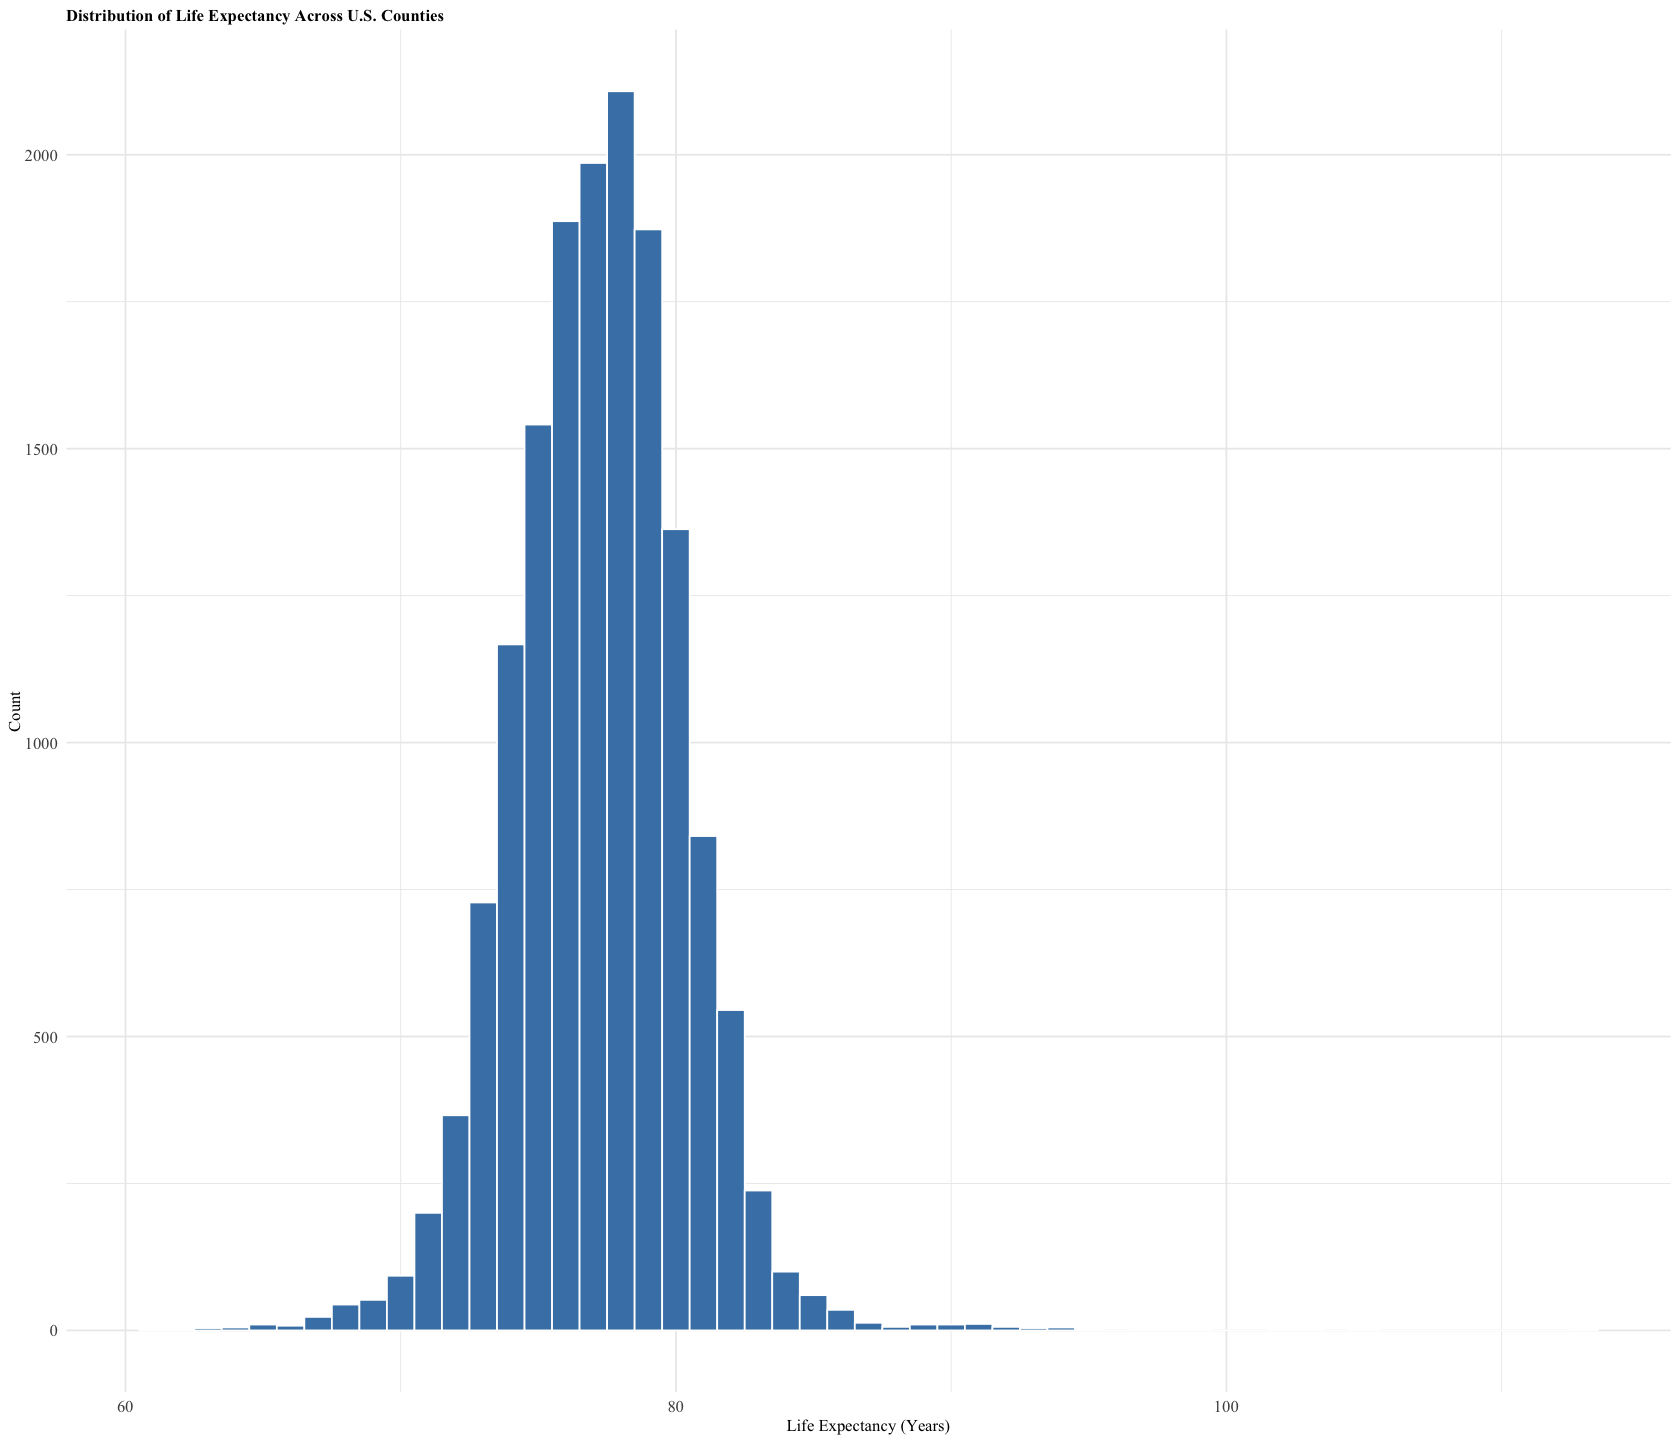

In [73]:
# Distribution of Life Expectancy
ggplot(merged_data, aes(x = Life_Expectancy)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  labs(title = "Distribution of Life Expectancy Across U.S. Counties",
       x = "Life Expectancy (Years)",
       y = "Count") +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 10, face = "bold", 
                              family = "Times New Roman"),
    axis.title = element_text(size = 10, family = "Times New Roman"),
    axis.text = element_text(size = 10, family = "Times New Roman")
  )

#### Key Observations from Life Expectancy Distribution

The distribution of life expectancy across U.S. counties is approximately normal, 
centered around a mean of 77.24 years. The distribution shows a slight right skew, 
with a small number of counties reporting unusually high life expectancy values 
approaching and exceeding 100 years. These extreme values are visible as isolated 
bars on the far right of the histogram and will be investigated in the outlier 
screening step. The bulk of counties fall between 70 and 85 years, which is 
consistent with national life expectancy estimates for the United States.

#### Outlier Screening

Outliers in the outcome variable are identified and investigated to determine 
whether they represent data quality issues or genuine extreme values.

In [38]:
# Outlier Screening
# Identify counties with Life Expectancy > 100
outliers <- merged_data[merged_data$Life_Expectancy > 100,
                         c("FIPS_Code", "County", "State", "Year",
                           "Life_Expectancy", "Total_Population")]

# Sort by life expectancy
outliers[order(-outliers$Life_Expectancy), ]

# Check how many outliers
nrow(outliers)

# Check what % of total data they represent
nrow(outliers) / nrow(merged_data) * 100

,FIPS_Code,County,State,Year,Life_Expectancy,Total_Population
,<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>
337,02013,Aleutians East Borough,NA,2021,113.4621,3337
338,02013,Aleutians East Borough,NA,2022,112.5039,3401
340,02013,Aleutians East Borough,NA,2023,112.5039,3398
1457,08113,San Miguel County,NA,2020,104.7401,8191
1032,06051,Mono County,NA,2023,103.3100,13247
1035,06051,Mono County,NA,2022,103.3100,14534
1458,08113,San Miguel County,NA,2021,102.9631,8179
1034,06051,Mono County,NA,2021,101.5982,14444


[1] 8

[1] 0.05208672

#### Outlier Screening Results

Eight county-year observations with life expectancy exceeding 100 
years are identified across three counties: Aleutians East Borough 
(AK), San Miguel County (CO), and Mono County (CA). These counties 
have very small populations where individual longevity can 
disproportionately inflate county-level averages.

All officially recorded county-level life expectancy values were retained in the analysis. No observations were removed on the basis of extreme values, as these represent valid recorded data from small but real counties.

#### Complete Case Analysis by Year

In [39]:
# Complete Case Analysis by Year
for(yr in c("2020", "2021", "2022", "2023")){
  year_data <- merged_data[merged_data$Year == yr, ]
  complete <- sum(complete.cases(year_data[, c("Annual Checkup", "Stroke", 
                                                "COPD", "Current Smoking",
                                                "Diabetes", "Depression",
                                                "Coronary Heart Disease", 
                                                "Obesity", "High Blood Pressure",
                                                "Mental Health", 
                                                "Chronic Kidney Disease",
                                                "Physical Inactivity", 
                                                "Physical Health")]))
  cat("Year:", yr, "- Complete cases:", complete, "\n")
}

Year: 2020 - Complete cases: 0 
Year: 2021 - Complete cases: 2700 
Year: 2022 - Complete cases: 0 
Year: 2023 - Complete cases: 0 


**Result:** Only 2021 has complete cases when requiring all 13 conditions. This means we cannot use all 13 conditions in the model without losing 2020 and 2023 entirely.

**Decision:** Drop the 5 conditions that are missing entire years: Current Smoking, High Blood Pressure, Mental Health, Chronic Kidney Disease, Physical Health.

Keeping 8 conditions that have data across 2020, 2021, and 2023: Annual Checkup, Stroke, COPD, Diabetes, Depression, Coronary Heart Disease, Obesity, Physical Inactivity.

In [42]:
# Drop the 5 conditions missing entire years
merged_data <- merged_data %>%
  select(-`Current Smoking`, -`High Blood Pressure`, -`Mental Health`,
         -`Chronic Kidney Disease`, -`Physical Health`)

# Verify - rows unchanged, only columns removed
cat("Columns remaining:", ncol(merged_data), "\n")
cat("Rows unchanged:", nrow(merged_data), "\n")
colnames(merged_data)

Columns remaining: 20 
Rows unchanged: 15359 


[1] "FIPS_Code"              "Year"                   "County"                
 [4] "Total_Population"       "Pct_Rural"              "State"                 
 [7] "Annual Checkup"         "Stroke"                 "COPD"                  
[10] "Diabetes"               "Depression"             "Coronary Heart Disease"
[13] "Obesity"                "Physical Inactivity"    "Uninsured_Total"       
[16] "Uninsured_Under19"      "Uninsured_19to64"       "Uninsured_65plus"      
[19] "Uninsured_Below100Pov"  "Life_Expectancy"

The 5 conditions are removed from the dataset. All subsequent EDA reflects only the 8 retained conditions and is consistent with the final model.

#### Check Linearity Assumption Before Modeling

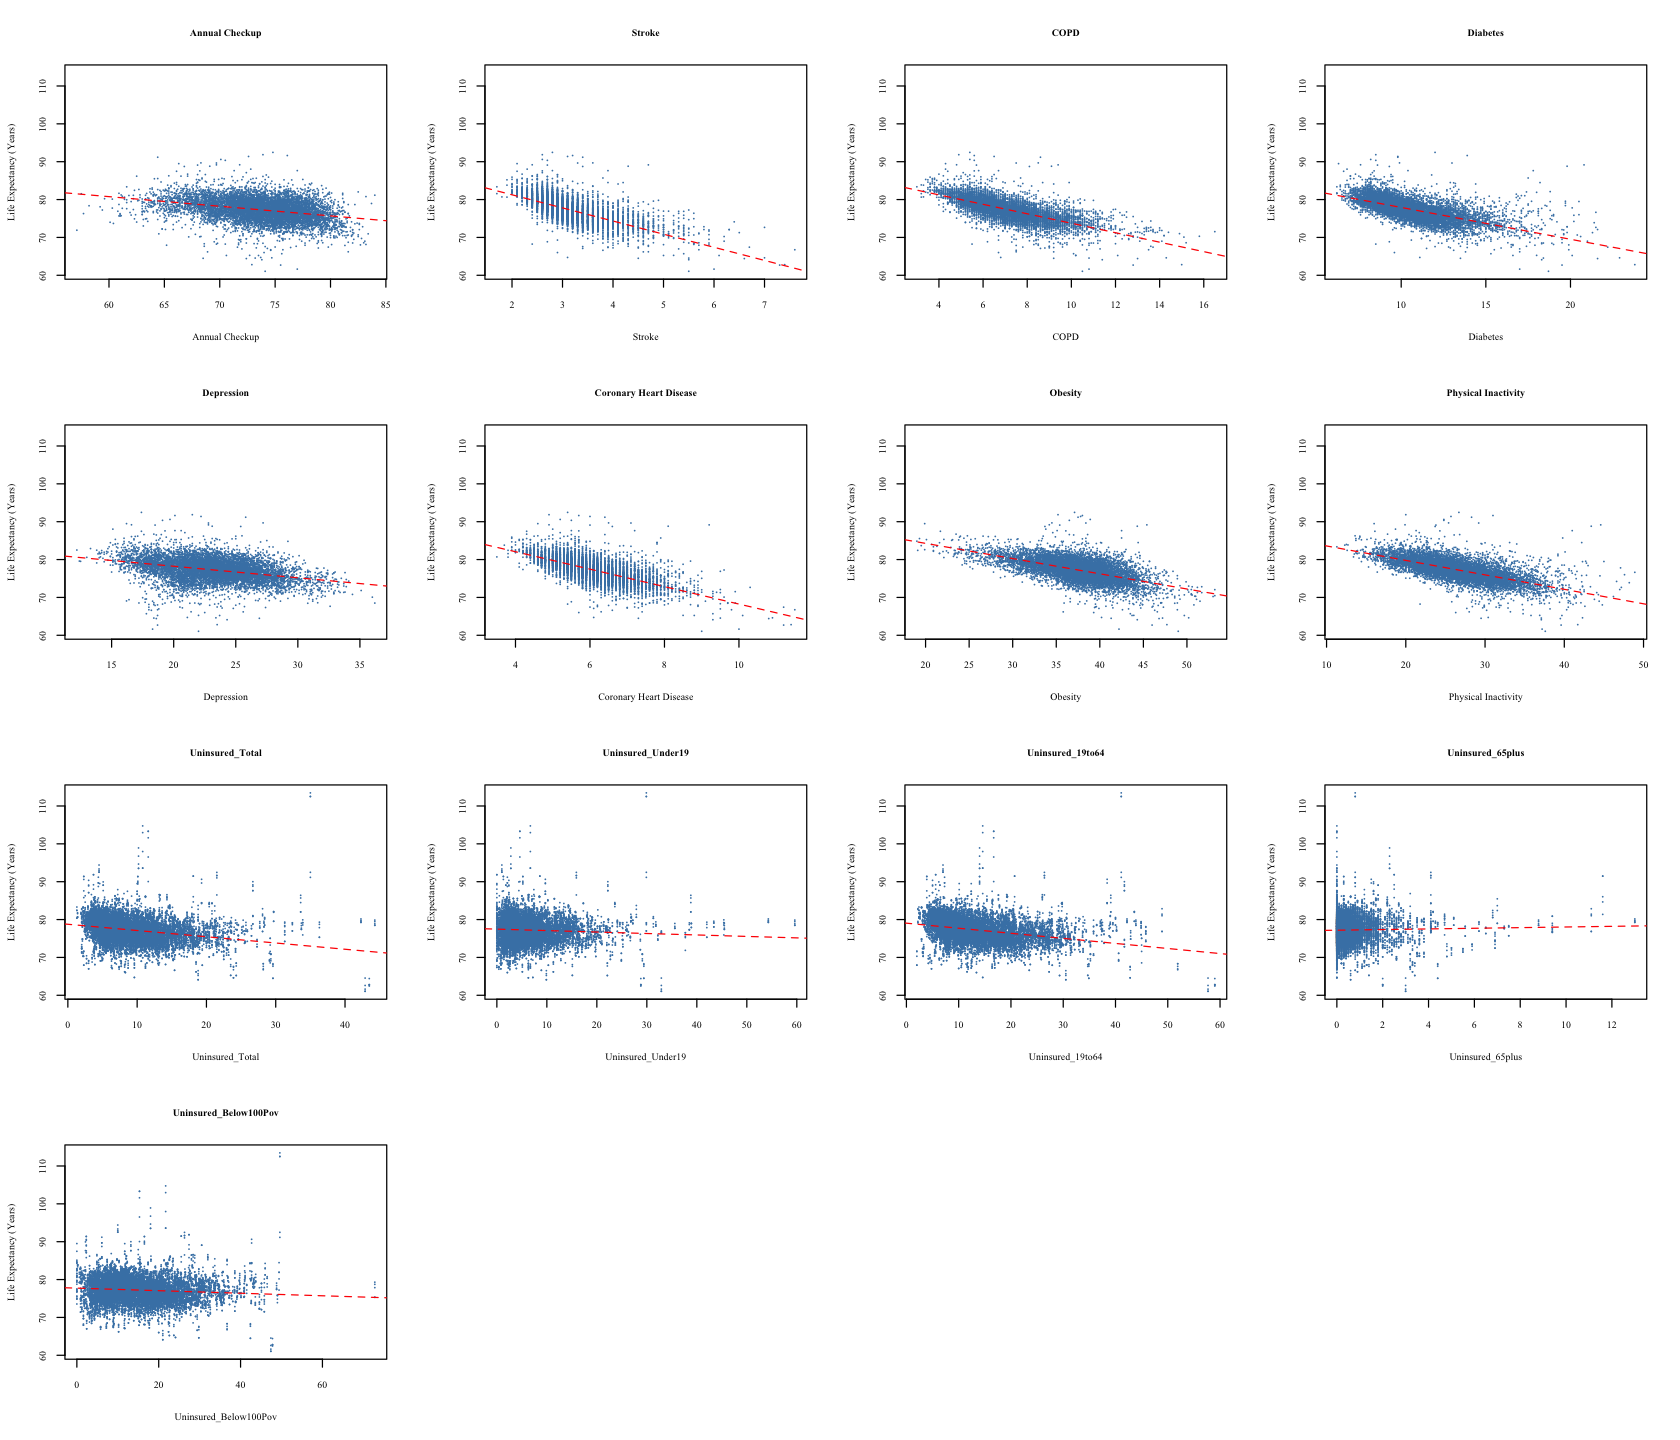

In [98]:
# Scatter plots of Life_Expectancy vs quantitative predictors
# Year is excluded as it is categorical, not appropriate for scatter plots

predictors_of_interest <- c("Annual Checkup", "Stroke", "COPD",
                             "Diabetes", "Depression", 
                             "Coronary Heart Disease", "Obesity",
                             "Physical Inactivity", "Uninsured_Total",
                             "Uninsured_Under19", "Uninsured_19to64",
                             "Uninsured_65plus", "Uninsured_Below100Pov")

par(mfrow = c(4, 4),
    family = "Times New Roman",
    cex.main = 0.75,
    cex.lab = 0.75,
    cex.axis = 0.75)

for(var in predictors_of_interest){
  plot(merged_data[[var]], merged_data$Life_Expectancy,
       xlab = var, ylab = "Life Expectancy (Years)",
       main = var, col = "steelblue", pch = 16, cex = 0.3)
  abline(lm(merged_data$Life_Expectancy ~ merged_data[[var]],
            na.action = na.omit), col = "red", lty = 2)
}

par(mfrow = c(1, 1),
    family = "",
    cex.main = 1,
    cex.lab = 1,
    cex.axis = 1)

#### Linearity Assessment Results

**Strong negative linear relationships (linearity holds):**
- Stroke: clear downward linear trend, tight scatter 
- COPD: clear downward linear trend 
- Obesity: clear downward linear trend 
- Physical Inactivity: clear downward linear trend 
- Diabetes: moderate downward trend 
- Coronary Heart Disease: moderate downward trend 
- Depression: moderate downward trend 

**Weak or unclear relationships:**
- Annual Checkup: nearly flat line, very wide scatter- weak relationship
- Uninsured_19to64: slight negative trend but very scattered
- Uninsured_Below100Pov: very weak, scattered
- Uninsured_Under19: nearly flat, very scattered
- Uninsured_65plus: nearly flat, almost no relationship

Overall, insurance status has less of a relationship with life expectancy than health conditions do.

Despite weaker relationships observed for some insurance variables, 
all predictors are retained and carried forward into modeling. Variable selection 
via Lasso will determine which predictors contribute meaningfully 
in the presence of all other variables.

#### Correlation Analysis

The relationships between each predictor and life expectancy are assessed through 
correlation coefficients to identify the most strongly associated variables prior to 
modeling.

In [47]:
# Correlation Analysis
# Select only numeric predictor columns and Life Expectancy
cor_data <- merged_data[, c("Annual Checkup", "Stroke", "COPD",
                             "Diabetes", "Depression",
                             "Coronary Heart Disease", "Obesity",
                             "Physical Inactivity", "Uninsured_Total",
                             "Uninsured_Under19", "Uninsured_19to64",
                             "Uninsured_65plus", "Uninsured_Below100Pov",
                             "Life_Expectancy")]

# Compute correlation matrix using complete cases
cor_matrix <- cor(cor_data, use = "complete.obs")

# Show correlations with Life Expectancy only
cor_with_outcome <- sort(cor_matrix[, "Life_Expectancy"], decreasing = TRUE)
cor_with_outcome

Life_Expectancy       Uninsured_65plus      Uninsured_Under19 
           1.000000000            0.004185182           -0.095217004 
 Uninsured_Below100Pov        Uninsured_Total         Annual Checkup 
          -0.139622397           -0.319553687           -0.328285192 
      Uninsured_19to64             Depression                Obesity 
          -0.358165826           -0.358707590           -0.588144144 
              Diabetes    Physical Inactivity Coronary Heart Disease 
          -0.643737755           -0.660904085           -0.682213956 
                  COPD                 Stroke 
          -0.701955995           -0.703310687

#### Correlation Analysis Results

**Strongest negative correlations (retained predictors):**
- Stroke (-0.703)
- COPD (-0.702)
- Coronary Heart Disease (-0.682)

**Weakest correlations (retained predictors):**
- Uninsured_65plus (+0.004)
- Uninsured_Under19 (-0.10)
- Uninsured_Below100Pov (-0.14)

These results are consistent with the linearity assessment. Variables 
with the strongest negative correlations also show the clearest 
downward trends in the scatter plots, while variables with near-zero 
correlations correspond to the flattest regression lines.

#### Correlation Heatmap

A heatmap visualization of the correlation matrix is generated to provide a 
comprehensive view of the relationships between all predictors and life expectancy.

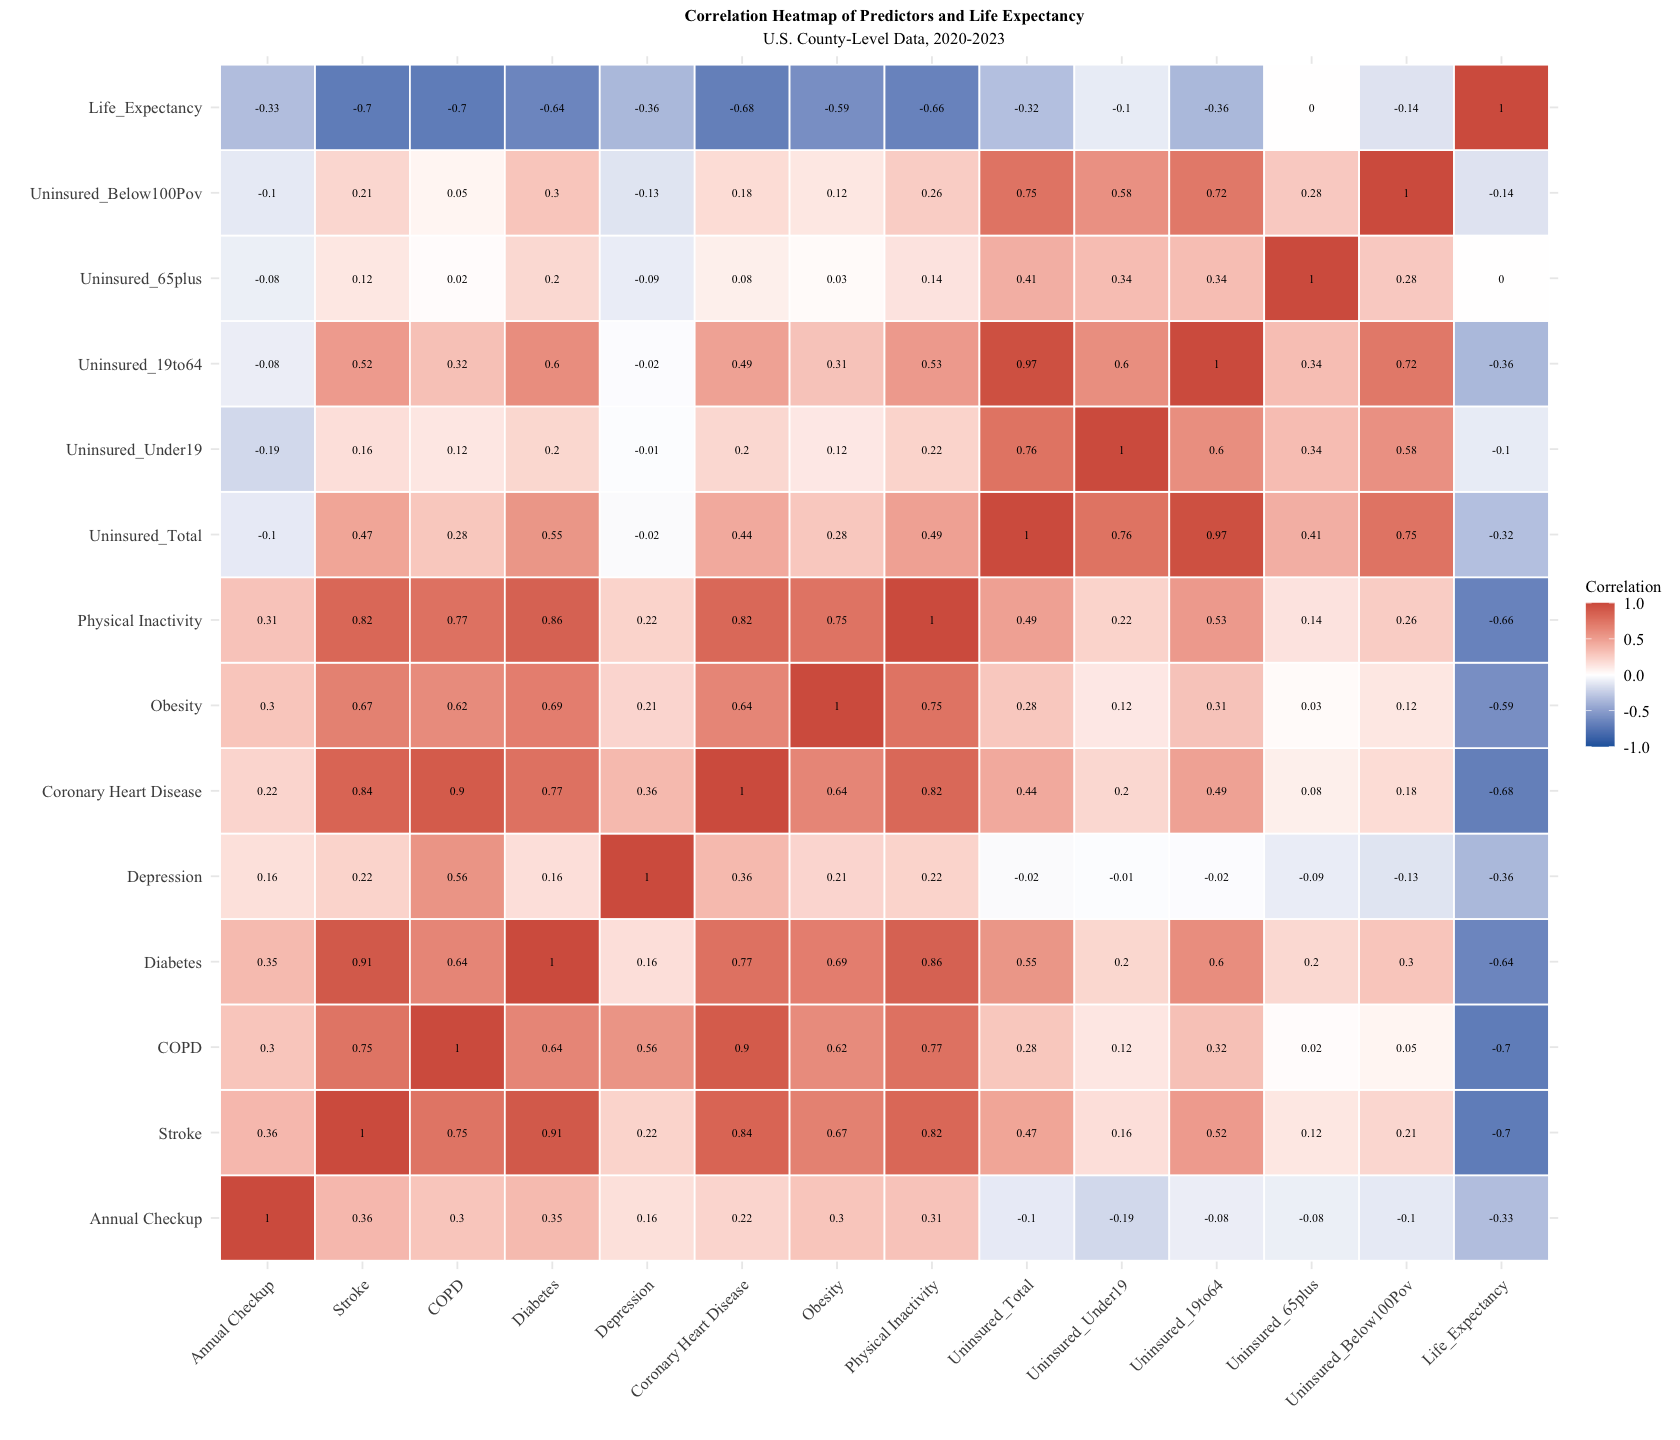

In [99]:
# Correlation Heatmap
library(reshape2)

# Round correlation values for display
cor_melted <- melt(cor_matrix)
cor_melted$value_rounded <- round(cor_melted$value, 2)

options(repr.plot.width = 14, repr.plot.height = 12)

ggplot(cor_melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = value_rounded), 
            size = 2.5, color = "black",
            family = "Times New Roman") +
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#D6604D",
                       midpoint = 0, limit = c(-1, 1),
                       name = "Correlation") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 10,
                                family = "Times New Roman"),
    axis.text.y = element_text(size = 10, family = "Times New Roman"),
    plot.title = element_text(hjust = 0.5, size = 10, face = "bold",
                              family = "Times New Roman"),
    plot.subtitle = element_text(hjust = 0.5, size = 10,
                                 family = "Times New Roman"),
    legend.title = element_text(size = 10, family = "Times New Roman"),
    legend.text = element_text(size = 10, family = "Times New Roman"),
    legend.position = "right"
  ) +
  labs(title = "Correlation Heatmap of Predictors and Life Expectancy",
       subtitle = "U.S. County-Level Data, 2020-2023",
       x = "", y = "")

The heatmap also shows high correlations among predictors themselves, 
particularly between health conditions and among insurance variables. This suggests potential multicollinearity, which will be formally assessed using VIF after 
model fitting.

### Geographic Distribution of Top Predictors

The strongest predictor of reduced life expectancy, Stroke, is mapped at the county level using the most recent 
available data per county (2020-2023). Darker magenta/purple indicates higher prevalence, lighter cyan 
indicates lower prevalence. Light gray counties have no available PLACES data and are excluded.

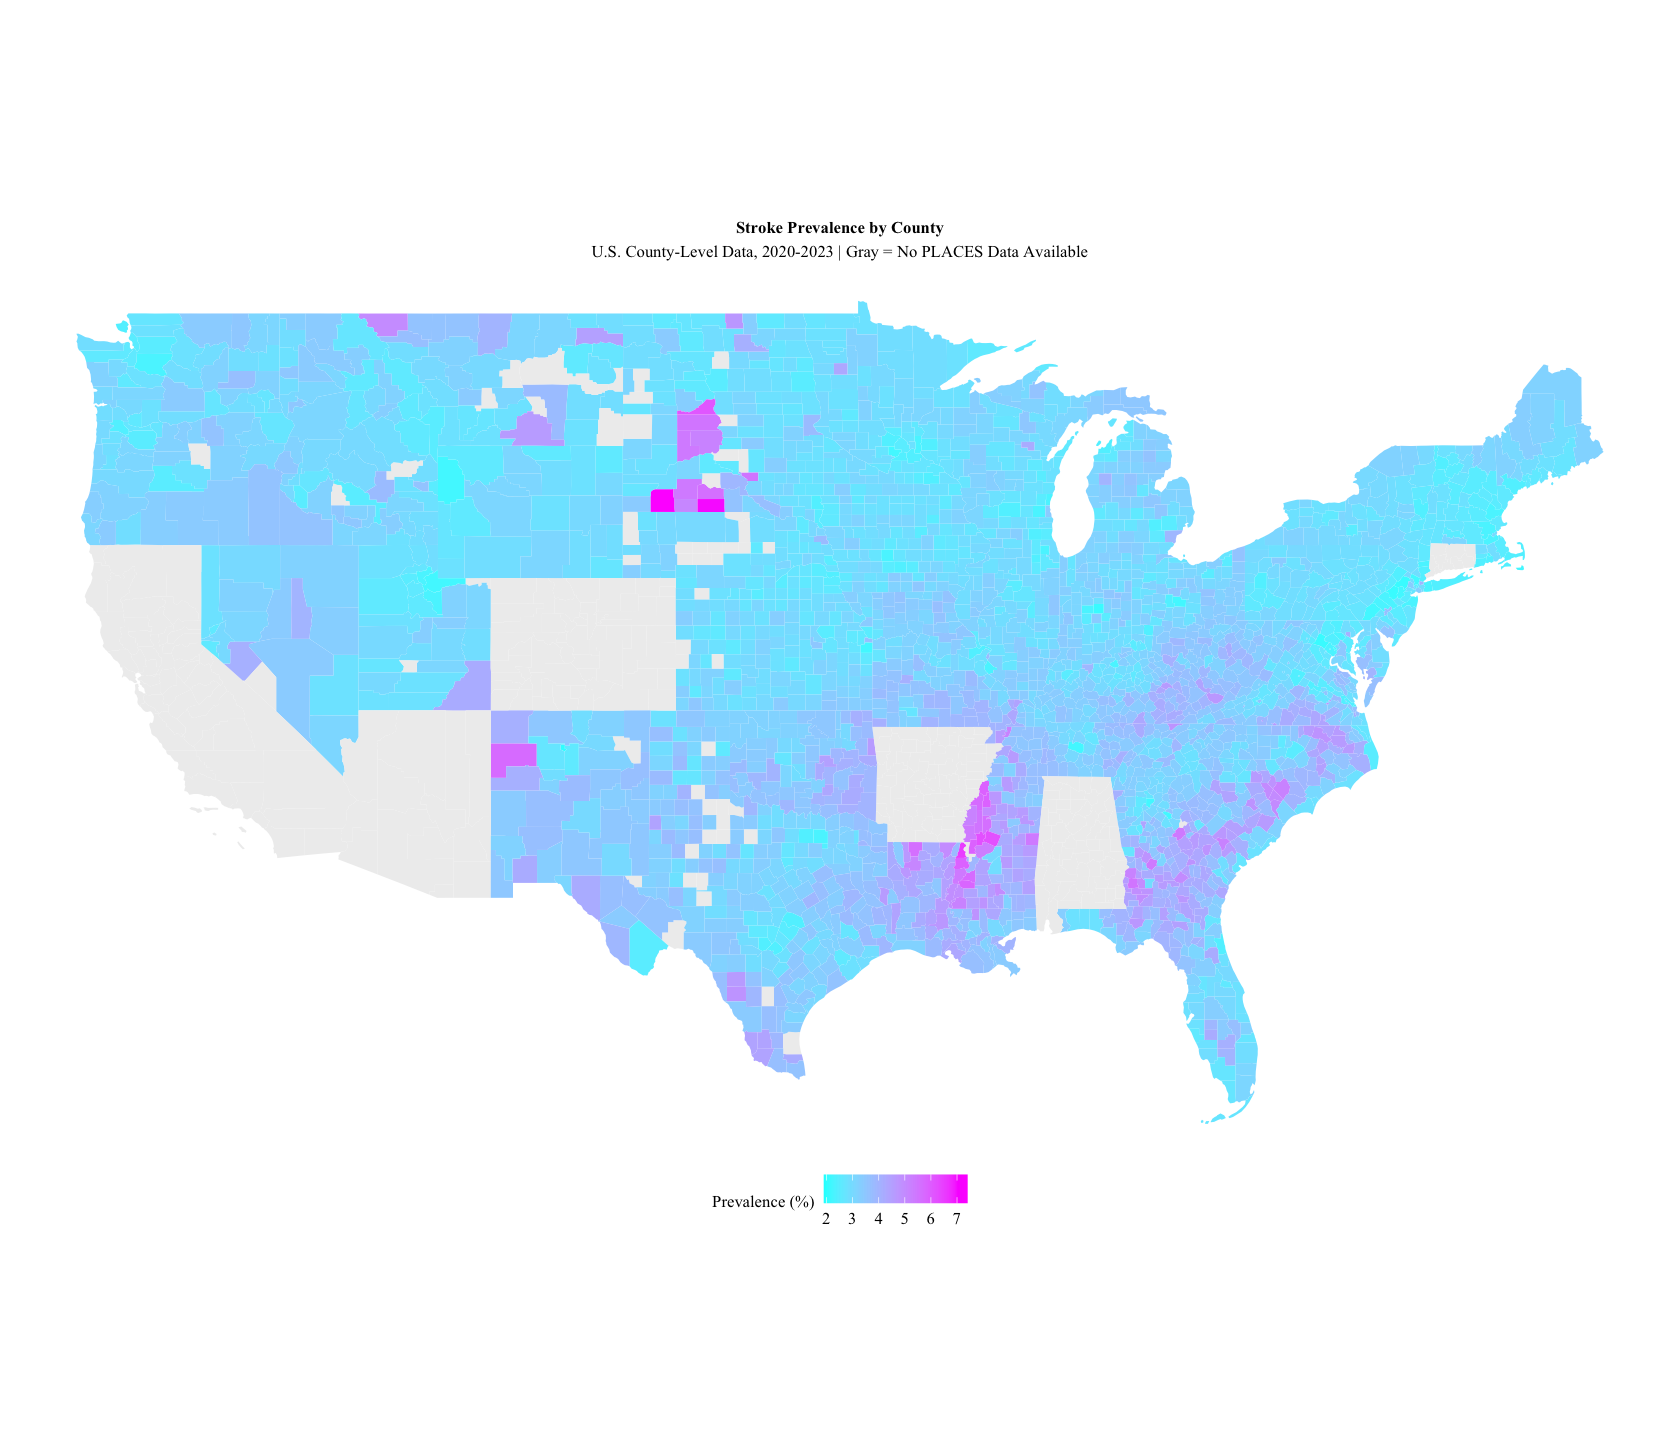

In [100]:
# Choropleth Map — Stroke Prevalence by County (Top Predictor)
# Using most recent available year per county to maximize coverage
# Cyan = low prevalence, Magenta = high prevalence

library(tigris)
library(sf)
library(dplyr)
library(ggplot2)

options(tigris_use_cache = TRUE)

# Get county shapefile
counties_sf <- counties(cb = TRUE, resolution = "20m", year = 2023)

# Use most recent available year per county
map_data <- merged_data %>%
  filter(!is.na(Stroke)) %>%
  arrange(FIPS_Code, desc(Year)) %>%
  group_by(FIPS_Code) %>%
  slice(1) %>%
  ungroup() %>%
  select(FIPS_Code, Stroke) %>%
  rename(GEOID = FIPS_Code)

# Merge with map data
county_map <- left_join(
  counties_sf %>% filter(!STATEFP %in% c("02", "15", "72")),
  map_data, by = "GEOID")

# Plot
ggplot(county_map, aes(fill = Stroke)) +
  geom_sf(color = NA) +
  scale_fill_gradient(low = "#00FFFF", high = "#FF00FF",
                      name = "Prevalence (%)",
                      na.value = "#EEEEEE") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 10,
                              face = "bold", family = "Times New Roman"),
    plot.subtitle = element_text(hjust = 0.5, size = 10,
                                 family = "Times New Roman"),
    legend.title = element_text(size = 10, family = "Times New Roman"),
    legend.text = element_text(size = 10, family = "Times New Roman"),
    legend.position = "bottom"
  ) +
  labs(title = "Stroke Prevalence by County",
       subtitle = "U.S. County-Level Data, 2020-2023 | Gray = No PLACES Data Available")

A clear geographic concentration is visible in the South and 
Appalachian region, consistent with the Life Expectancy by State 
plot where Southern states showed the lowest mean life expectancy.

Note: Six states (Alabama, Arizona, Arkansas, California, 
Colorado, and Connecticut) appear gray due to the absence of 
Stroke prevalence data in the CDC PLACES dataset across all 
available years (2020-2023). This is a known coverage limitation 
of the PLACES dataset and does not reflect a data processing error.

#### Life Expectancy by Year

While year is treated as a categorical control variable rather than a continuous 
time trend in the regression model, the distribution of life expectancy across 
years is examined to validate this decision. If distributions are stable across 
years, treating year categorically is appropriate. 

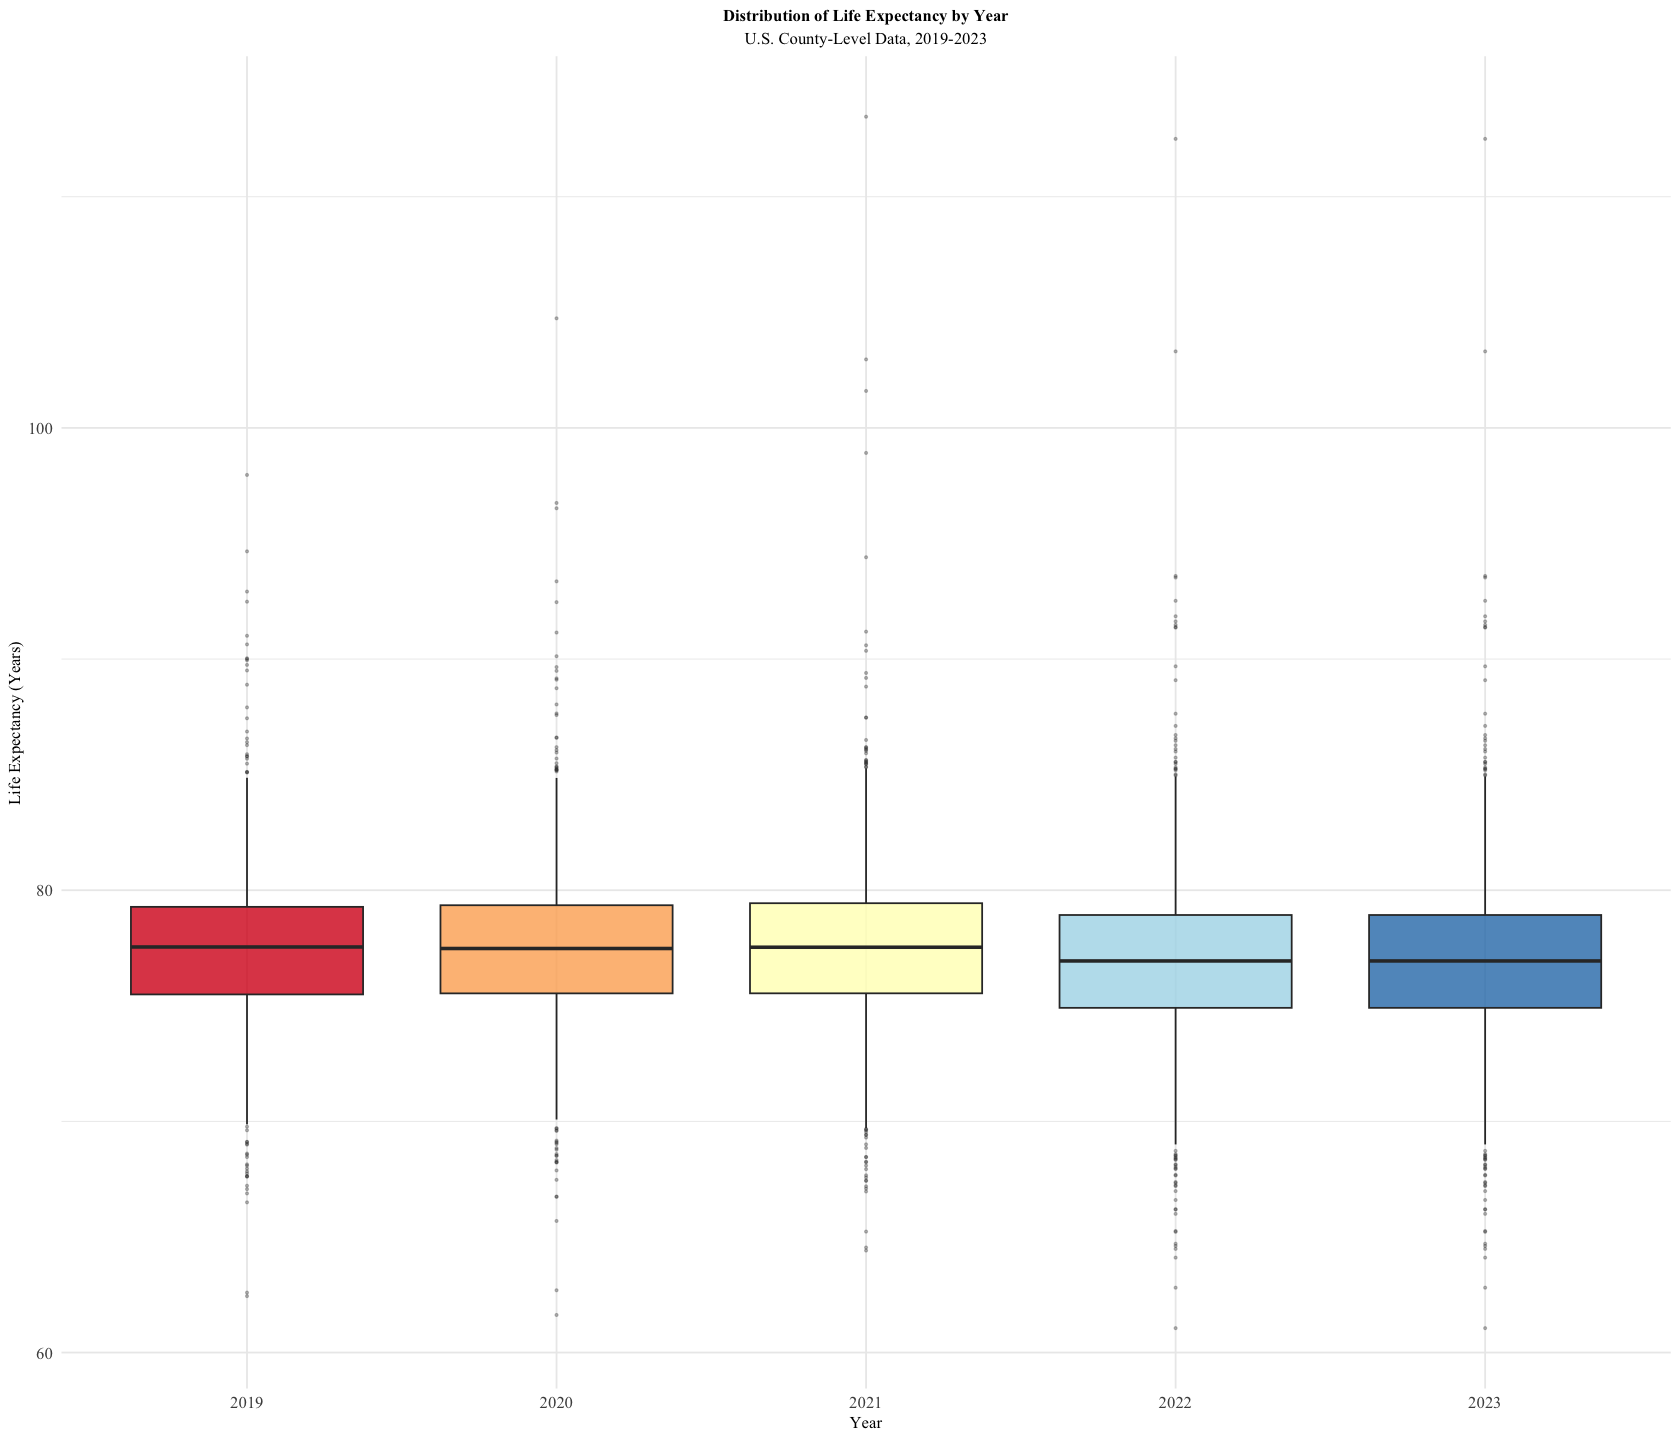

In [101]:
# Life Expectancy by Year
ggplot(merged_data, aes(x = Year, y = Life_Expectancy, fill = Year)) +
  geom_boxplot(alpha = 0.8, outlier.size = 0.5, outlier.alpha = 0.3) +
  scale_fill_brewer(palette = "RdYlBu") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 10, face = "bold",
                              family = "Times New Roman"),
    plot.subtitle = element_text(hjust = 0.5, size = 10,
                                 family = "Times New Roman"),
    axis.title = element_text(size = 10, family = "Times New Roman"),
    axis.text = element_text(size = 10, family = "Times New Roman"),
    legend.position = "none"
  ) +
  labs(title = "Distribution of Life Expectancy by Year",
       subtitle = "U.S. County-Level Data, 2019-2023",
       x = "Year", y = "Life Expectancy (Years)")

#### Life Expectancy by Year Results

Life expectancy distributions remain relatively stable across the study period, 
with median values consistently around 77 years. A slight decline is observed in 
2022 and 2023, which may reflect the lingering effects of the COVID-19 pandemic. 

However, the overall stability of distributions across years supports the decision to treat year as a categorical control variable.

### Data Preparation for Modeling

From the 15,359 rows in the merged dataset, variables used in 
modeling are selected and listwise deletion is applied 
to remove any rows with missing values, resulting in 8,039 complete 
cases. The reduction is primarily due to 
2019 and 2022 having no complete health condition data.

A binary outcome variable is created for logistic regression. Counties at or above the national mean life expectancy (77.24 years) are coded as 1, below as 0. 
Data is split 70/30 into training (5,627 rows) and test (2,412 rows) 
sets using a random seed of 100.

In [49]:
# Select modeling variables and apply listwise deletion
# Identifier columns (FIPS_Code, County, State) excluded
# 5 dropped conditions already removed from merged_data earlier
model_data <- merged_data %>%
  select(Life_Expectancy, Year, Total_Population, Pct_Rural,
         `Annual Checkup`, Stroke, COPD,
         Diabetes, Depression, `Coronary Heart Disease`, Obesity,
         `Physical Inactivity`,
         Uninsured_Total, Uninsured_Under19, Uninsured_19to64,
         Uninsured_65plus, Uninsured_Below100Pov) %>%
  na.omit()

# Create binary outcome variable for logistic regression
# 1 = at or above national mean life expectancy (77.24 years)
# 0 = below national mean life expectancy
model_data$Life_Exp_Binary <- ifelse(model_data$Life_Expectancy >= 77.24, 1, 0)

# Train/test split (70/30)
# Seed set for reproducibility
set.seed(100)
train_index <- sample(1:nrow(model_data), 0.7 * nrow(model_data))
train_data <- model_data[train_index, ]
test_data  <- model_data[-train_index, ]

# Verify
cat("Total rows after listwise deletion:", nrow(model_data), "\n")
cat("Training rows:", nrow(train_data), "\n")
cat("Test rows:", nrow(test_data), "\n\n")
cat("Year distribution in model data:\n")
print(table(model_data$Year))
cat("\nBinary outcome distribution:\n")
print(table(model_data$Life_Exp_Binary))

Total rows after listwise deletion: 8039 
Training rows: 5627 
Test rows: 2412 

Year distribution in model data:

2019 2020 2021 2022 2023 
   0 2762 2699    0 2578 

Binary outcome distribution:

   0    1 
3832 4207 


As expected, 2019 and 2022 show zero rows, 2019 was excluded from 
the PLACES dataset entirely, and 2022 was dropped during listwise 
deletion due to missing health condition data. The three remaining 
years (2020, 2021, 2023) contribute roughly equal numbers of rows.

The binary outcome is reasonably balanced: 3,832 counties below 
the national mean (0) and 4,207 above (1), a roughly 48/52 split. 

### Variable Selection: Lasso

Lasso regression 
is used for variable selection to help
identify the most meaningful predictors while reducing model 
complexity.

Lasso is run on the training set only to prevent data leakage, the test set remains unseen until model evaluation. 
Cross-validation is used to find the optimal penalty value (lambda).

In [79]:
# Variable Selection: Lasso
# Run on training set only to prevent data leakage
# alpha = 1 specifies Lasso (alpha = 0 would be Ridge)

library(glmnet)

X_train <- model.matrix(Life_Expectancy ~ . - Life_Exp_Binary, 
                         data = train_data)[, -1]
y_train <- train_data$Life_Expectancy

# Run cross-validated Lasso on training set
set.seed(100)
lasso_cv <- cv.glmnet(X_train, y_train, alpha = 1)

# Best lambda
best_lambda <- lasso_cv$lambda.min
cat("Best lambda:", best_lambda, "\n")

# Lasso coefficients at best lambda
lasso_coef <- coef(lasso_cv, s = "lambda.min")
print(lasso_coef)

# Extract selected variables (non-zero coefficients)
selected_vars <- rownames(lasso_coef)[which(lasso_coef != 0)]
selected_vars <- selected_vars[selected_vars != "(Intercept)"]
cat("Selected variables:\n")
print(selected_vars)

Best lambda: 0.001739641 
20 x 1 sparse Matrix of class "dgCMatrix"
                            lambda.min
(Intercept)               9.068222e+01
Year2020                 -4.150387e-01
Year2021                  2.863674e-01
Year2022                  .           
Year2023                  .           
Total_Population          4.544984e-07
Pct_Rural                 7.275387e-01
`Annual Checkup`         -1.701683e-02
Stroke                   -2.056186e+00
COPD                     -9.161854e-01
Diabetes                  7.471883e-02
Depression               -7.107486e-02
`Coronary Heart Disease`  1.085084e+00
Obesity                  -1.025367e-01
`Physical Inactivity`    -3.355290e-02
Uninsured_Total          -2.046600e-01
Uninsured_Under19         8.331338e-02
Uninsured_19to64          6.441823e-02
Uninsured_65plus          2.423724e-01
Uninsured_Below100Pov    -1.281575e-02
Selected variables:
 [1] "Year2020"                 "Year2021"                
 [3] "Total_Population"         "P

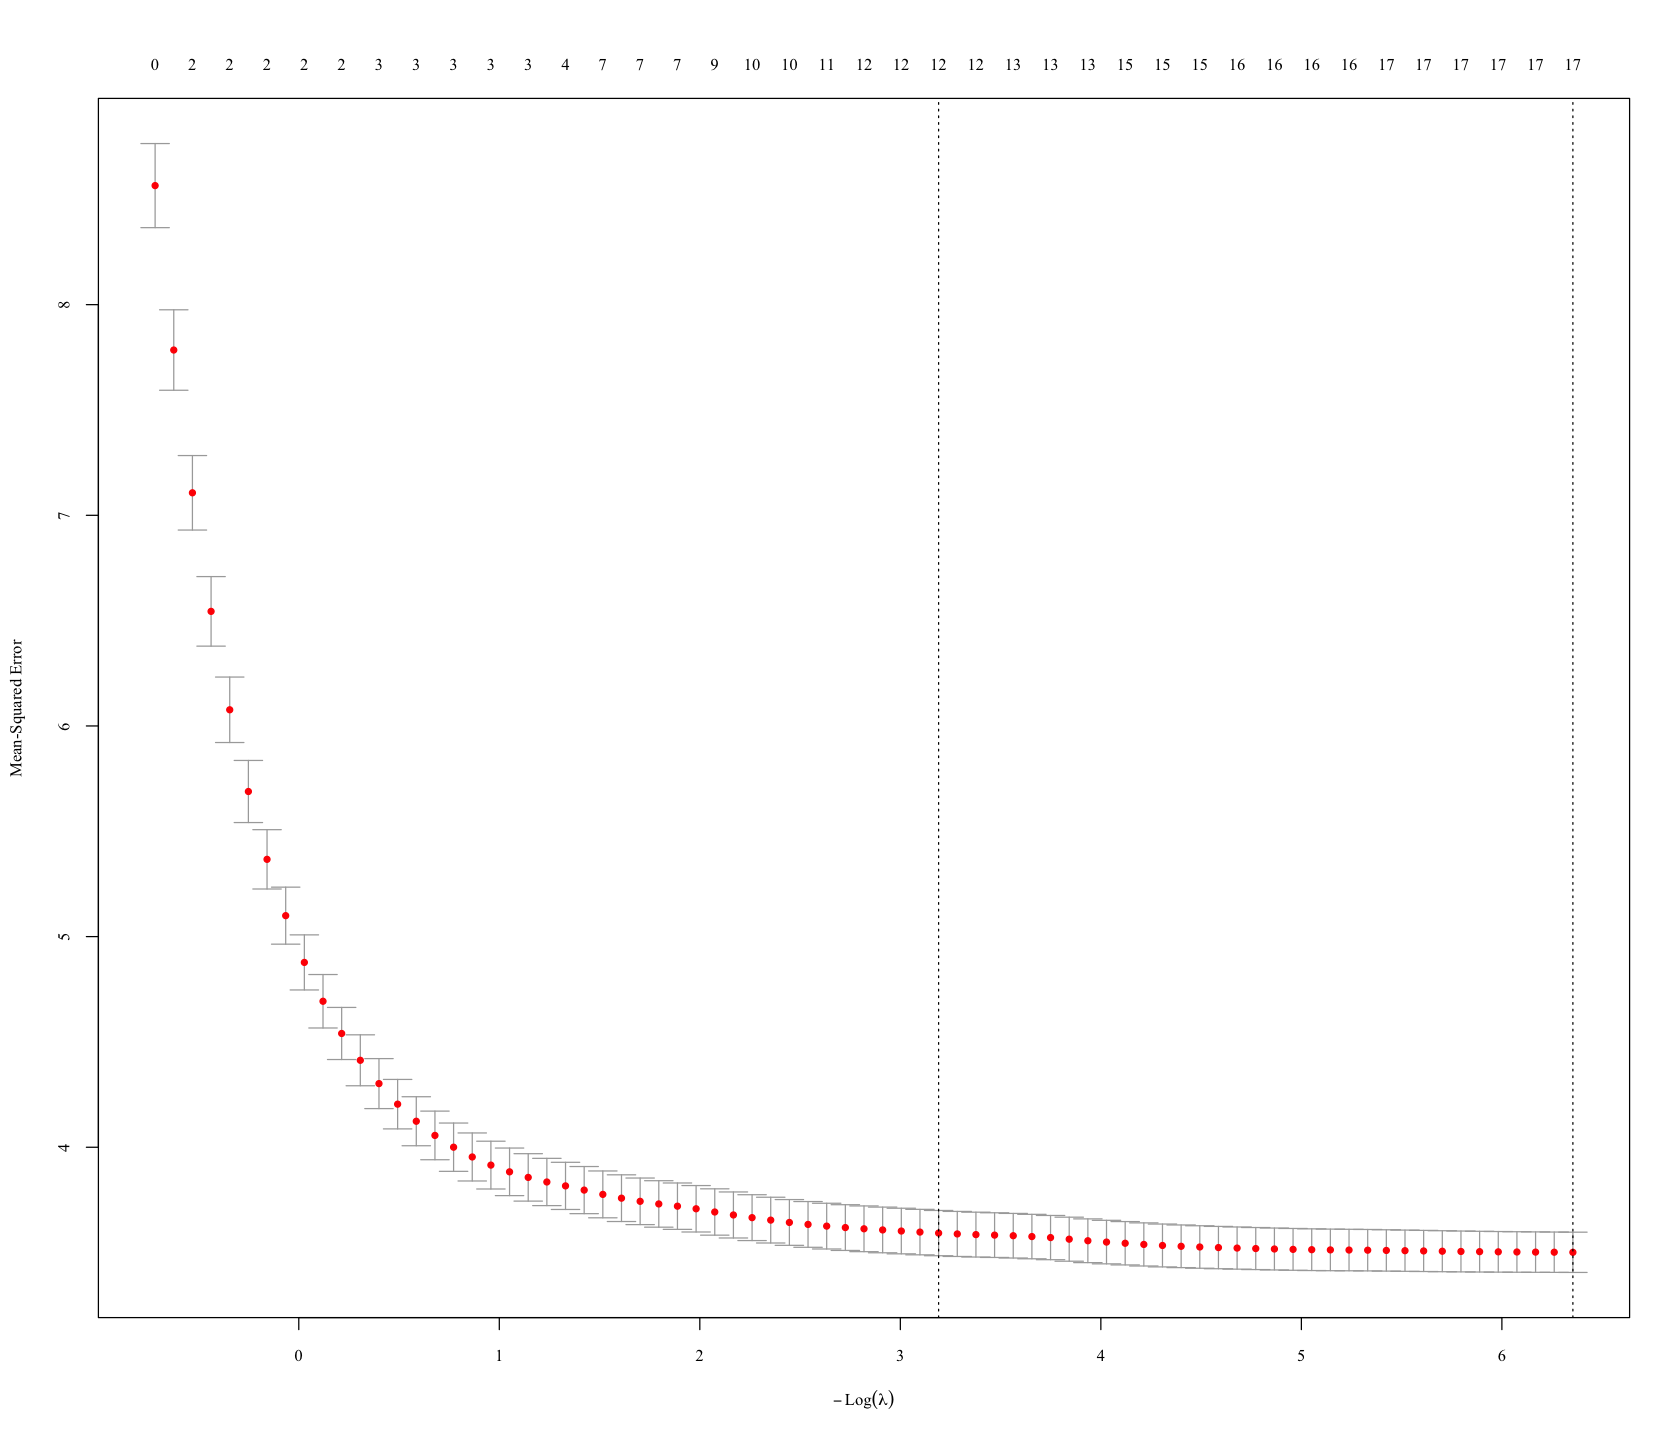

In [114]:
# Lasso Cross-Validation Plot
par(family = "Times New Roman",
    cex.main = 0.833,
    cex.lab = 0.833,
    cex.axis = 0.833)

plot(lasso_cv)

par(family = "",
    cex.main = 1,
    cex.lab = 1,
    cex.axis = 1)

#### Lasso Results

Best lambda: 0.00174

#### Lasso Cross-Validation Results

The cross-validation plot shows MSE minimized at λ.min = 0.00174 
(left dashed line), which is selected as the optimal penalty. 
At this lambda, all 15 predictors of interest retain non-zero 
coefficients — confirmed by the coefficient output above. 
Year 2022 and 2023 levels are zeroed out but Year is retained 
in full as a categorical control variable regardless of these results.

All 15 predictors of interest were retained, none of the health 
conditions or insurance variables were eliminated, confirming that 
each contributes meaningful predictive information.

Within the Year control variable, the 2022 and 2023 levels were 
zeroed out by Lasso. However, Year is retained in full as a 
categorical control variable in all models regardless of 
these resuls. Removing specific year 
levels would compromise the integrity of the time control.

All 15 predictors of interest are carried forward into modeling, as the purpose of Lasso here 
is variable selection guidance rather than strict elimination.

### Multiple Linear Regression (Training Set)

A multiple linear regression model is fit on the training set to 
predict county-level life expectancy as a continuous outcome. 
The model includes 15 predictors of interest plus Year as a 
categorical control variable, Total_Population and Pct_Rural 
as continuous control variables, 17 predictors in total.

In [51]:
# Multiple Linear Regression on training set
linear_model <- lm(Life_Expectancy ~ Year + Total_Population + Pct_Rural +
                     `Annual Checkup` + Stroke + COPD + Diabetes + Depression +
                     `Coronary Heart Disease` + Obesity + `Physical Inactivity` +
                     Uninsured_Total + Uninsured_Under19 + Uninsured_19to64 +
                     Uninsured_65plus + Uninsured_Below100Pov,
                   data = train_data)

summary(linear_model)


Call:
lm(formula = Life_Expectancy ~ Year + Total_Population + Pct_Rural + 
    `Annual Checkup` + Stroke + COPD + Diabetes + Depression + 
    `Coronary Heart Disease` + Obesity + `Physical Inactivity` + 
    Uninsured_Total + Uninsured_Under19 + Uninsured_19to64 + 
    Uninsured_65plus + Uninsured_Below100Pov, data = train_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-12.9354  -1.0122  -0.0435   0.9481  15.0892 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)               8.989e+01  7.832e-01 114.768  < 2e-16 ***
Year2021                  7.509e-01  9.210e-02   8.152 4.37e-16 ***
Year2023                  4.476e-01  9.478e-02   4.723 2.38e-06 ***
Total_Population          4.797e-07  1.186e-07   4.045 5.30e-05 ***
Pct_Rural                 6.933e-01  1.046e-01   6.627 3.75e-11 ***
`Annual Checkup`         -1.395e-02  8.687e-03  -1.606  0.10829    
Stroke                   -2.137e+00  1.346e-01 -15.875  < 2e-16 ***
COP

#### Multiple Linear Regression Results (Training Set)

The model explains approximately 59.6% of the variation in 
county-level life expectancy on the training set (R^2 = 0.596), 
with an overall F-statistic of 487.3 (p < 2.2e-16) confirming 
the model is highly significant.

**Significant predictors:**
- Stroke: -2.06 years (p < 0.001)
- COPD: -0.92 years (p < 0.001)
- Uninsured_Total: -0.20 years (p < 0.001)
- Coronary Heart Disease: +1.09 years (p < 0.001) — counterintuitive 
positive sign, likely due to multicollinearity with Stroke and COPD
- Pct_Rural: +0.69 years (p < 0.001)

**Not significant:**
- Annual Checkup: p = 0.10

### Test Set Performance

The fitted model is applied to the held-out test set (2,412 rows) 
to evaluate prediction performance on unseen data.

In [96]:
# Model fitted on training set, evaluated on test set

test_predictions <- predict(linear_model, newdata = test_data)

test_residuals <- test_data$Life_Expectancy - test_predictions
RMSE <- sqrt(mean(test_residuals^2))
MAE <- mean(abs(test_residuals))
R2_test <- cor(test_data$Life_Expectancy, test_predictions)^2

cat("Test Set Performance:\n")
cat("RMSE:", round(RMSE, 4), "\n")
cat("MAE:", round(MAE, 4), "\n")
cat("R-squared:", round(R2_test, 4), "\n")

Test Set Performance:
RMSE: 1.7773 
MAE: 1.2849 
R-squared: 0.616 


#### Test Set Results 

The linear regression model was evaluated on the held-out test set 
of 2,412 rows. 

- **RMSE = 1.777** — on average, predictions are off by 1.777 years
- **MAE = 1.285** — the typical prediction error is 1.285 years
- **R² = 0.616** — the model explains 61.6% of the variation in 
life expectancy on unseen data

The test R^2 (0.616) is slightly higher than the training R^2 (0.596), 
indicating the model generalizes well to unseen data with no signs 
of overfitting.

### VIF: Multicollinearity Check

With 15 predictors in the model, many of which are biologically 
related, multicollinearity 
is a concern. Variance Inflation Factors (VIF) are computed for each 
predictor to formally assess this.

The threshold used is VIF < max(10, 1/(1 - R^2)) where R^2 is the 
model R^2. A VIF of 1 means no correlation with other predictors;
the higher the VIF, the more problematic the multicollinearity.

In [53]:
# Multicollinearity Check — VIF
# Module 2 requirement when working with many correlated predictors
# Threshold: VIF < max(10, 1/(1 - R2_model))

library(car)

vif_values <- vif(linear_model)
print(vif_values)

# Compute threshold
r2_model <- summary(linear_model)$r.squared
threshold <- max(10, 1 / (1 - r2_model))
cat("\nModel R-squared:", round(r2_model, 4), "\n")
cat("VIF threshold:", round(threshold, 4), "\n")

# Flag variables exceeding threshold
high_vif <- vif_values[vif_values[, 1] > threshold, ]
if(nrow(high_vif) > 0){
  cat("\nVariables exceeding VIF threshold:\n")
  print(high_vif)
} else {
  cat("\nNo variables exceed the VIF threshold.\n")
}

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




                               GVIF Df GVIF^(1/(2*Df))
Year                       3.688211  2        1.385811
Total_Population           1.404986  1        1.185321
Pct_Rural                  1.703204  1        1.305069
`Annual Checkup`           1.724876  1        1.313345
Stroke                    10.168820  1        3.188859
COPD                      13.480071  1        3.671522
Diabetes                  11.287081  1        3.359625
Depression                 2.602736  1        1.613300
`Coronary Heart Disease`  21.561984  1        4.643488
Obesity                    2.805081  1        1.674838
`Physical Inactivity`      7.821517  1        2.796698
Uninsured_Total          103.026485  1       10.150196
Uninsured_Under19          9.612890  1        3.100466
Uninsured_19to64          63.784892  1        7.986544
Uninsured_65plus           1.547767  1        1.244093
Uninsured_Below100Pov      2.595204  1        1.610964

Model R-squared: 0.5963 
VIF threshold: 10 

Variables exceeding

#### VIF Results

VIF threshold = 10. Six variables exceed this threshold:

- **Coronary Heart Disease** (21.56)
- **Uninsured_Total** (103.03) 
- **Uninsured_19to64** (63.78)
- **COPD** (13.48)
- **Diabetes** (11.29)
- **Stroke** (10.17)

High VIFs among health conditions are expected given their 
biological relatedness. Uninsured_Total's extremely high VIF 
is explained by its mathematical overlap with Uninsured_19to64. 
No variables are removed. Variable selection via Lasso already 
retained all 15 predictors, and high VIFs among biologically 
related health conditions and structurally overlapping insurance 
variables are expected given the nature of the data. Individual 
coefficient interpretation for high-VIF predictors such as 
Coronary Heart Disease should be made with caution.

### Goodness of Fit and Model Assumption Checks - Linear Regression

Model assumptions are evaluated using residual diagnostic plots. 
Four plots are examined: 

- Residuals vs fitted values (linearity and constant variance)
- Normal QQ plot (normality)
- Histogram of residuals (normality)
- Residuals vs Stroke - the strongest predictor (linearity with respect to key predictor)

Warning message in axis(side = side, at = at, labels = labels, ...):
“font family 'Times New Roman' not found in PostScript font database”
Warning message in axis(side = side, at = at, labels = labels, ...):
“font family 'Times New Roman' not found in PostScript font database”
Warning message in axis(side = side, at = at, labels = labels, ...):
“font family 'Times New Roman' not found in PostScript font database”
Warning message in axis(side = side, at = at, labels = labels, ...):
“font family 'Times New Roman' not found in PostScript font database”
Warning message in axis(side = side, at = at, labels = labels, ...):
“font family 'Times New Roman' not found in PostScript font database”
Warning message in axis(side = side, at = at, labels = labels, ...):
“font family 'Times New Roman' not found in PostScript font database”
Warning message in axis(side = side, at = at, labels = labels, ...):
“font family 'Times New Roman' not found in PostScript font database”
Warning message in axis(sid

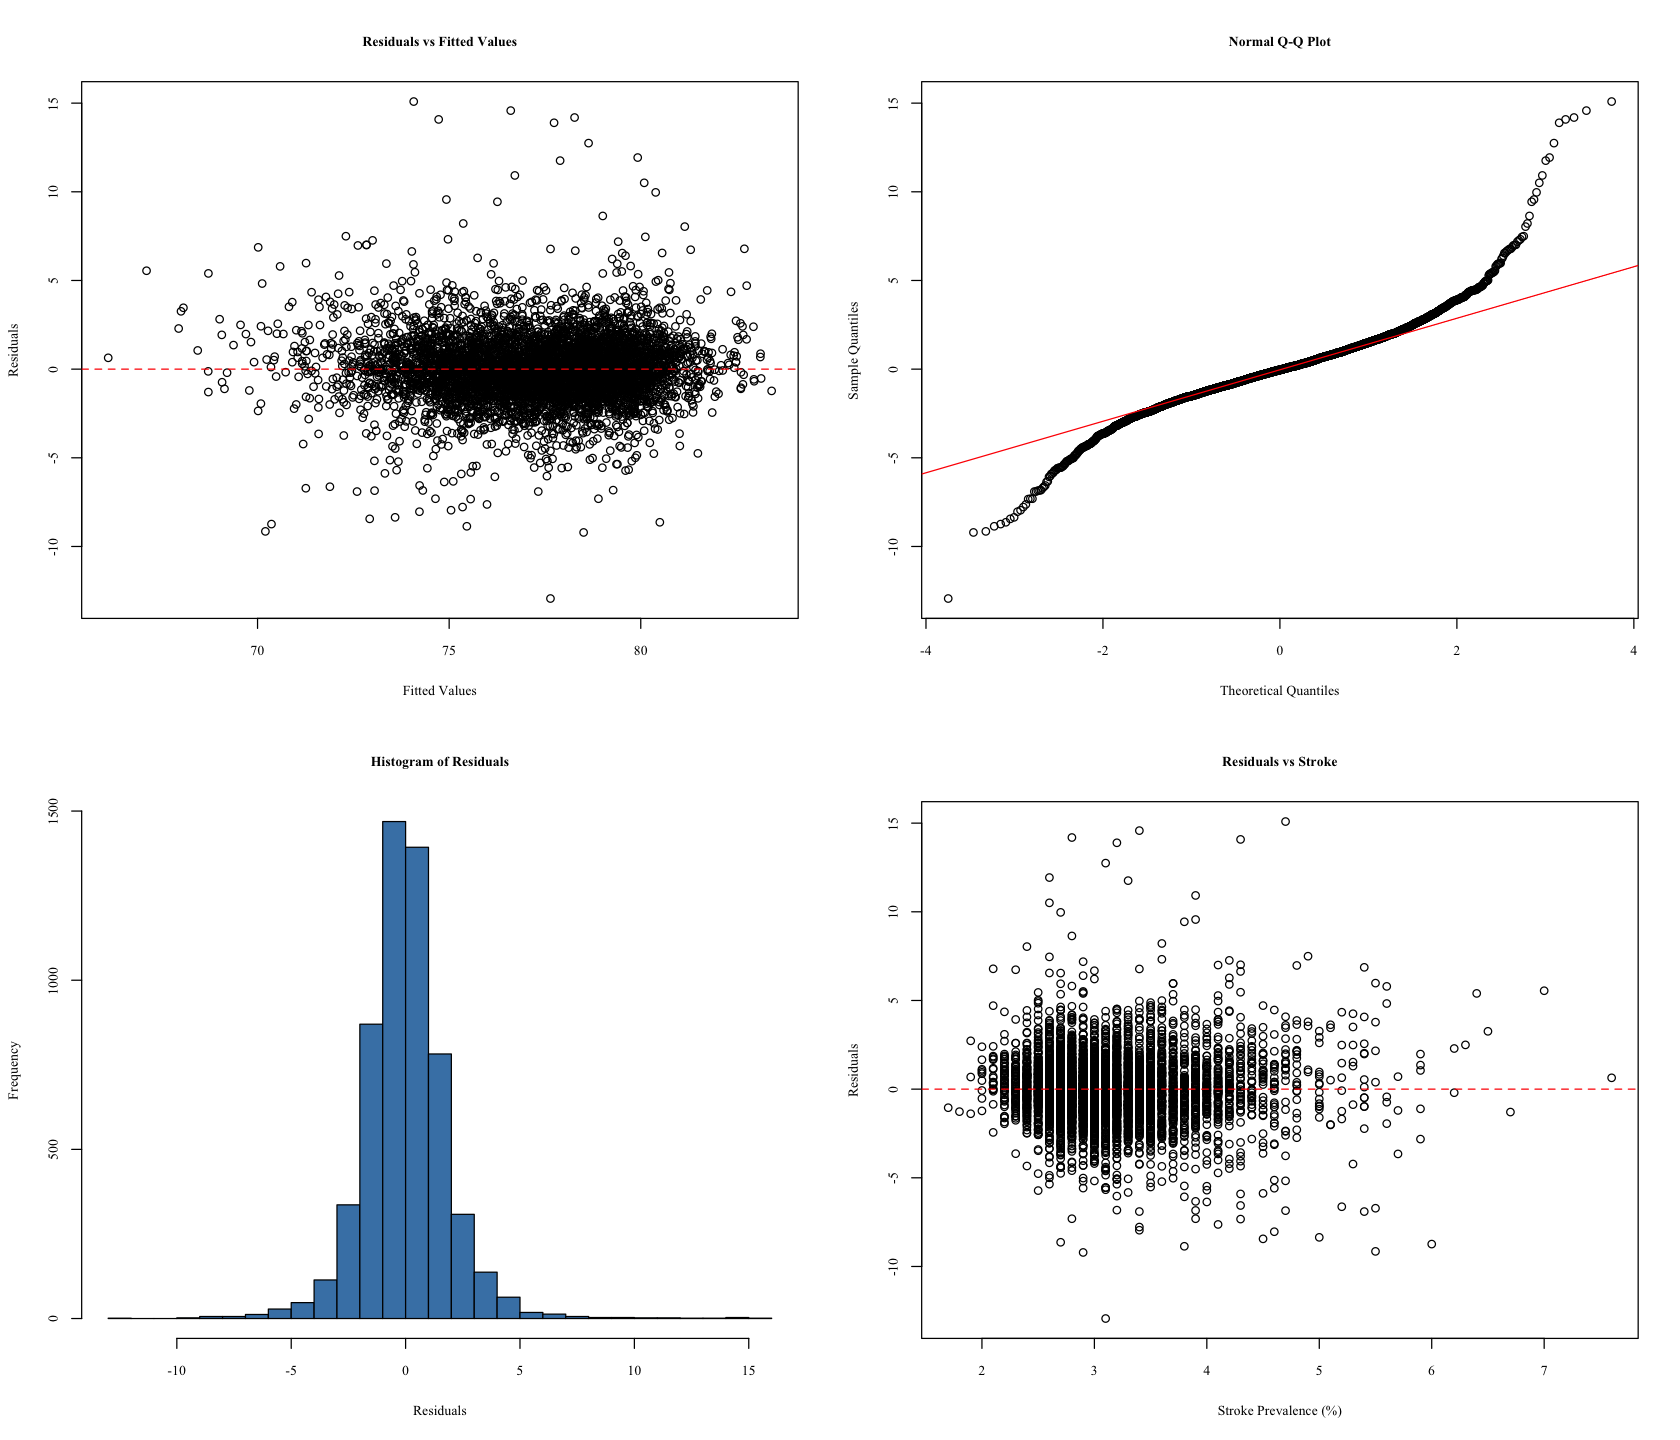

In [80]:
# Goodness of Fit — Linear Regression
# Evaluates: linearity, constant variance, normality, independence

par(mfrow = c(2, 2),
    family = "Times New Roman",
    cex.main = 0.833,
    cex.lab = 0.833,
    cex.axis = 0.833)

# Plot 1: Residuals vs Fitted - evaluates linearity and constant variance
plot(linear_model$fitted.values, linear_model$residuals,
     xlab = "Fitted Values", ylab = "Residuals",
     main = "Residuals vs Fitted Values")
abline(h = 0, lty = 2, col = "red")

# Plot 2: Normal QQ Plot - evaluates normality
qqnorm(linear_model$residuals, main = "Normal Q-Q Plot")
qqline(linear_model$residuals, col = "red")

# Plot 3: Histogram of Residuals - evaluates normality
hist(linear_model$residuals, breaks = 30,
     xlab = "Residuals", main = "Histogram of Residuals",
     col = "steelblue")

# Plot 4: Residuals vs Stroke - evaluates linearity with strongest predictor
plot(train_data$Stroke, linear_model$residuals,
     xlab = "Stroke Prevalence (%)", ylab = "Residuals",
     main = "Residuals vs Stroke")
abline(h = 0, lty = 2, col = "red")

par(mfrow = c(1, 1),
    family = "",
    cex.main = 1,
    cex.lab = 1,
    cex.axis = 1)

#### Goodness of Fit Results — Linear Regression

**Residuals vs Fitted:** Random scatter around zero, linearity 
holds. Mild fanning at higher fitted values suggests slight 
heteroscedasticity but not severe enough to invalidate the model.

**Normal QQ Plot:** Follows reference line in the middle but 
deviates at both tails, mild non-normality. Mitigated by large 
sample size (n = 8,039).

**Histogram of Residuals:** Approximately symmetric and unimodal, centered at zero, normality holds.

**Residuals vs Stroke:** No pattern, linearity assumption holds 
for the strongest predictor.

**Overall:** Model assumptions are largely satisfied.

### Logistic Regression

A logistic regression model is fit on the training set to classify 
counties as above or below the national mean life expectancy 
(77.24 years). 

The same 15 predictors and 3 control variables used 
in the linear model are retained. This model complements the linear 
regression by reframing the question as a classification problem:
identifying which counties are underperforming relative to the 
national average.

In [56]:
# Logistic Regression
# Binary outcome: 1 = at or above national mean (77.24 years)
#                 0 = below national mean
# Same predictors as linear model

logistic_model <- glm(Life_Exp_Binary ~ Year + Total_Population + Pct_Rural +
                        `Annual Checkup` + Stroke + COPD + Diabetes + Depression +
                        `Coronary Heart Disease` + Obesity + `Physical Inactivity` +
                        Uninsured_Total + Uninsured_Under19 + Uninsured_19to64 +
                        Uninsured_65plus + Uninsured_Below100Pov,
                      data = train_data,
                      family = binomial)

summary(logistic_model)


Call:
glm(formula = Life_Exp_Binary ~ Year + Total_Population + Pct_Rural + 
    `Annual Checkup` + Stroke + COPD + Diabetes + Depression + 
    `Coronary Heart Disease` + Obesity + `Physical Inactivity` + 
    Uninsured_Total + Uninsured_Under19 + Uninsured_19to64 + 
    Uninsured_65plus + Uninsured_Below100Pov, family = binomial, 
    data = train_data)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)               1.013e+01  1.234e+00   8.204 2.33e-16 ***
Year2021                  1.257e+00  1.508e-01   8.337  < 2e-16 ***
Year2023                  8.146e-01  1.533e-01   5.314 1.07e-07 ***
Total_Population          6.776e-07  2.647e-07   2.559 0.010487 *  
Pct_Rural                 5.436e-01  1.635e-01   3.325 0.000884 ***
`Annual Checkup`          2.761e-02  1.340e-02   2.061 0.039294 *  
Stroke                   -2.426e+00  2.515e-01  -9.645  < 2e-16 ***
COPD                     -1.185e+00  9.695e-02 -12.221  < 2e-16 ***
Diabetes      

#### Logistic Regression Results (Training Set)

The model shows a strong improvement from null deviance (7,786.8) 
to residual deviance (4,429.1), a 43% reduction, confirming the 
predictors collectively explain substantial variation in whether a 
county falls above or below the national mean life expectancy.

**Significant predictors (p < 0.05):**
- Stroke: -2.43 (p < 0.001) — strongest negative effect, consistent 
with linear model
- COPD: -1.19 (p < 0.001)
- Coronary Heart Disease: +1.83 (p < 0.001) — same counterintuitive 
positive sign as linear model, consistent with multicollinearity
- Depression: -0.10 (p < 0.001)
- Obesity: -0.09 (p < 0.001)
- Physical Inactivity: -0.07 (p < 0.001)
- Uninsured_Under19: +0.11 (p < 0.001)
- Uninsured_65plus: +0.25 (p < 0.001)
- Annual Checkup: +0.03 (p = 0.039) — marginally significant

**Not significant (p > 0.05):**
- Diabetes (p = 0.670)
- Uninsured_19to64 (p = 0.702)
- Uninsured_Total (p = 0.081)
- Uninsured_Below100Pov (p = 0.094)

Both models agree on the dominant predictors, Stroke and COPD 
are the strongest drivers in both the linear and logistic models, 
strengthening confidence in these findings.

#### Test Set Performance - Logistic Regression

The fitted logistic model is applied to the held-out test set 
(2,412 rows) to evaluate classification performance on unseen data.

In [57]:
# Test Set Performance — Logistic Regression
# Predicted probabilities converted to binary using 0.5 threshold

# Predicted probabilities
test_probs <- predict(logistic_model, newdata = test_data, type = "response")

# Convert to binary predictions using 0.5 threshold
test_pred_binary <- ifelse(test_probs >= 0.5, 1, 0)

# Confusion matrix
conf_matrix <- table(Predicted = test_pred_binary, 
                     Actual = test_data$Life_Exp_Binary)
print(conf_matrix)

# Accuracy
accuracy <- sum(diag(conf_matrix)) / sum(conf_matrix)
cat("Accuracy:", round(accuracy, 4), "\n")

         Actual
Predicted    0    1
        0  902  192
        1  256 1062
Accuracy: 0.8143 


#### Test Set Results — Logistic Regression

**Confusion Matrix:**

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | 902 (TN) | 256 (FP) |
| **Actual 1** | 192 (FN) | 1,062 (TP) |

- **Accuracy = 81.43%** — the model correctly classified 81% of 
counties as above or below the national mean life expectancy
- **True Positives = 1,062** - counties correctly identified as 
above average
- **True Negatives = 902** - counties correctly identified as 
below average
- **False Positives = 256** - counties incorrectly predicted as 
above average
- **False Negatives = 192** - counties incorrectly predicted as 
below average

The model performs well on both classes with no severe imbalance 
between false positives and false negatives.

#### Goodness of Fit - Logistic Regression

Goodness of fit for logistic regression is evaluated using two 
formal hypothesis tests and the ROC curve. For the deviance and 
Pearson tests, the null hypothesis is that the model fits well.

In [58]:
# Goodness of Fit — Logistic Regression
# Deviance and Pearson tests 
# H0: model fits well  H1: model does not fit well
# Large p-values indicate good fit (opposite of usual)

# Deviance test
deviance_test <- c(deviance(logistic_model),
                   1 - pchisq(deviance(logistic_model),
                               df.residual(logistic_model)))
cat("Deviance GOF Test:\n")
cat("Chi-squared statistic:", round(deviance_test[1], 3), "\n")
cat("P-value:", round(deviance_test[2], 4), "\n\n")

# Pearson residuals test
pearson_res <- residuals(logistic_model, type = "pearson")
pearson_tvalue <- sum(pearson_res^2)
pearson_test <- c(pearson_tvalue,
                  1 - pchisq(pearson_tvalue, df.residual(logistic_model)))
cat("Pearson GOF Test:\n")
cat("Chi-squared statistic:", round(pearson_test[1], 3), "\n")
cat("P-value:", round(pearson_test[2], 4), "\n")

Deviance GOF Test:
Chi-squared statistic: 4429.114 
P-value: 1 

Pearson GOF Test:
Chi-squared statistic: 7446.495 
P-value: 0 


Setting levels: control = 0, case = 1

Setting direction: controls < cases



AUC: 0.8974 


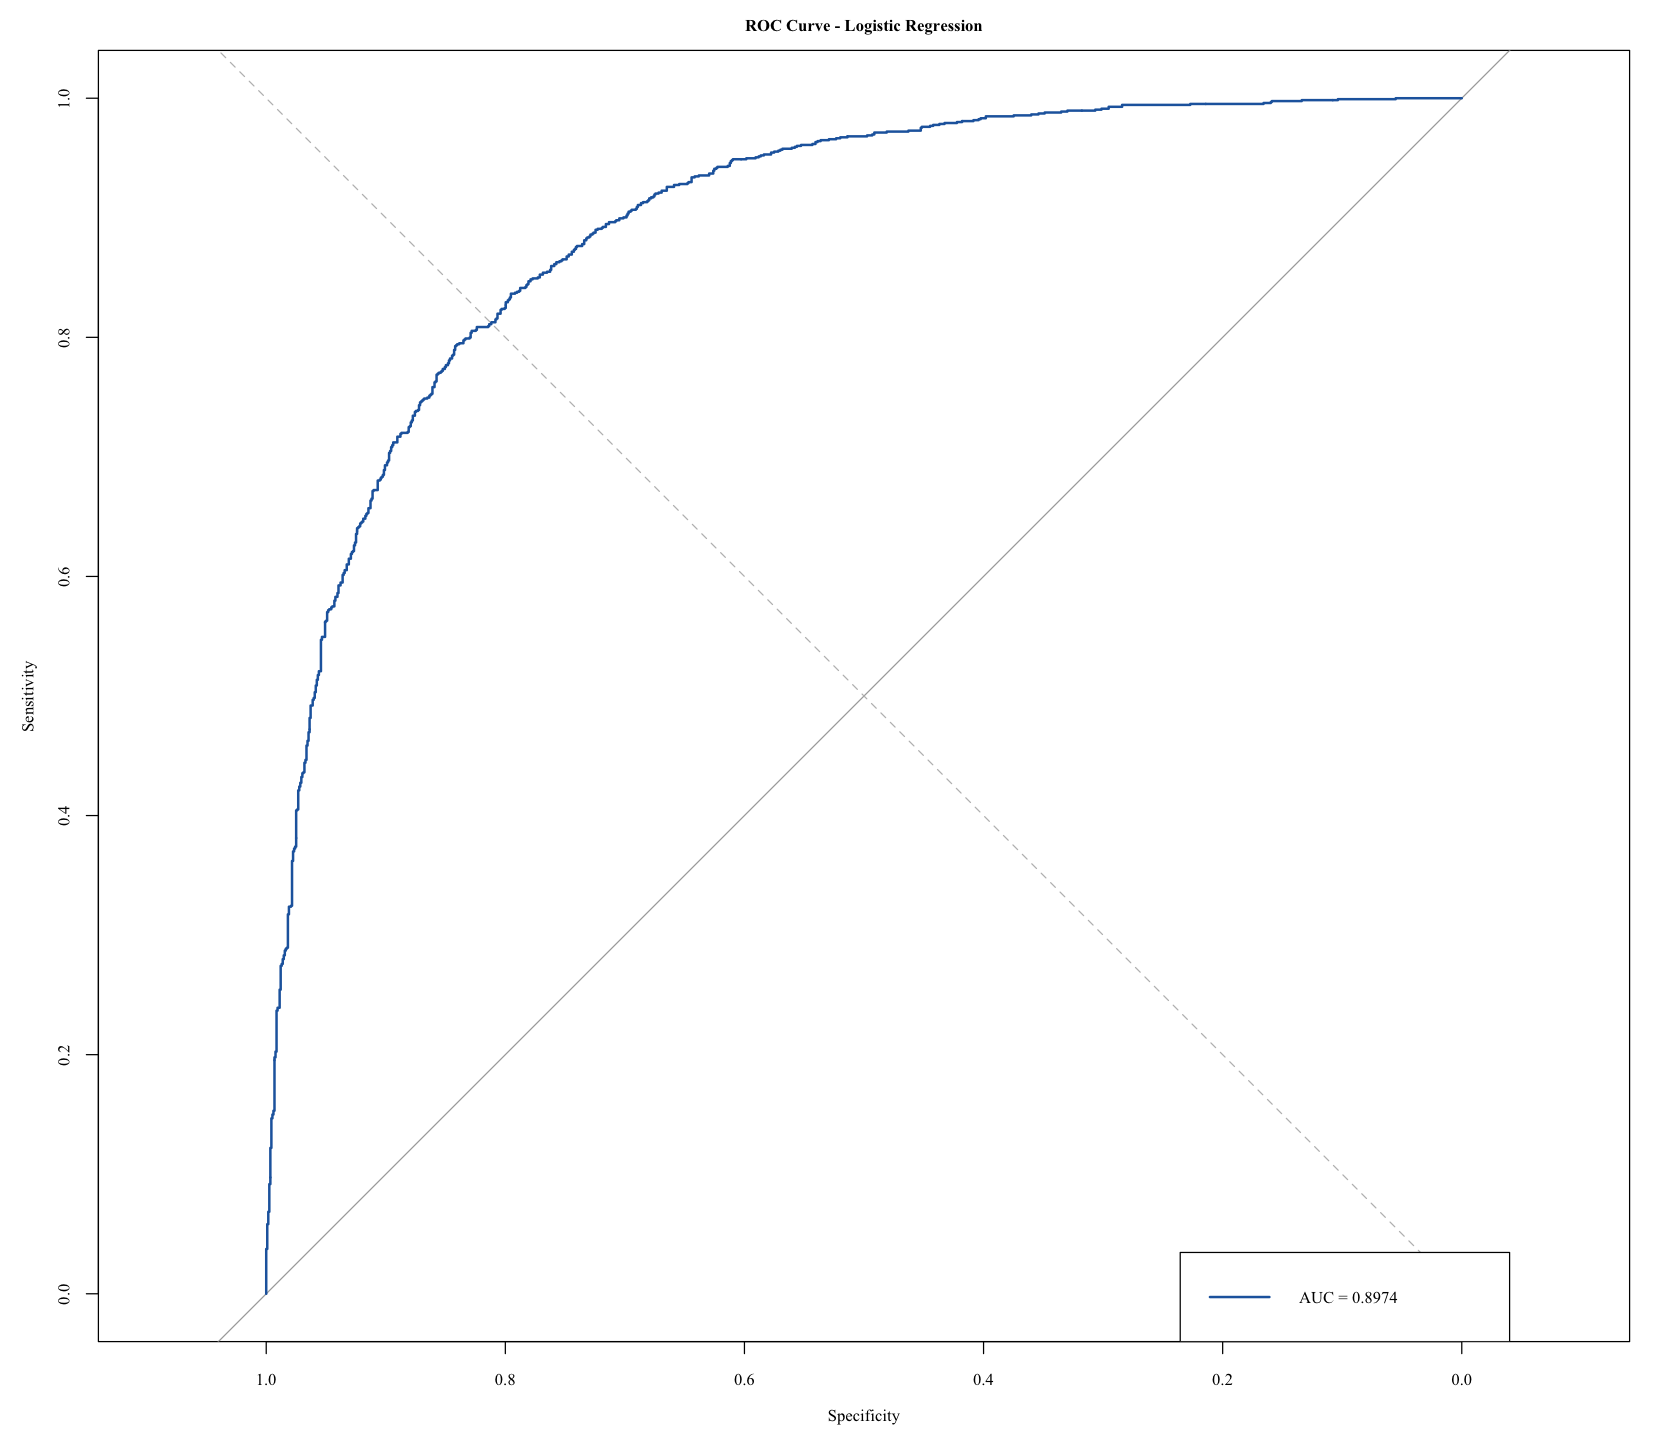

In [107]:
# ROC Curve and AUC
# Evaluates discriminative ability of the logistic model
# AUC closer to 1 = better, 0.5 = random guessing

library(pROC)

roc_curve <- roc(test_data$Life_Exp_Binary, test_probs)

par(family = "Times New Roman",
    cex.main = 0.833,
    cex.lab = 0.833,
    cex.axis = 0.833)

plot(roc_curve,
     main = "ROC Curve - Logistic Regression",
     col = "#2166AC",
     lwd = 2)
abline(a = 0, b = 1, lty = 2, col = "gray")

auc_value <- auc(roc_curve)
cat("AUC:", round(auc_value, 4), "\n")

legend("bottomright",
       legend = paste("AUC =", round(auc_value, 4)),
       col = "#2166AC", lwd = 2,
       cex = 0.833)

par(family = "",
    cex.main = 1,
    cex.lab = 1,
    cex.axis = 1)

#### Goodness of Fit Results — Logistic Regression

**Deviance Test:**
- Chi-squared statistic: 4,429.11
- P-value: 1.0: accept H0, model fits well 

**Pearson Test:**
- Chi-squared statistic: 7,446.50
- P-value: 0.0: reject H0, model does not fit well 

The two tests give conflicting results. This is not uncommon with 
large datasets. With 8,039 observations, even minor deviations from 
perfect fit can produce a significant result. The deviance test is 
generally considered more reliable for logistic regression.

**ROC Curve:**
- AUC = 0.8974: the model correctly distinguishes above vs below 
average life expectancy counties approximately 89.74% of the time
- AUC > 0.8 is considered excellent discriminative ability.
- The curve rises steeply toward the top-left corner, confirming 
strong classification performance.

Overall, the ROC curve and deviance test both indicate the model 
performs well despite the Pearson test result.

### Cross-Validation

10-fold cross-validation is applied to both models on the full 
model dataset to confirm performance is consistent 
and no overfitting has occurred. 

In [60]:
# Cross-Validation - 10-fold
# Applied to full model_data to confirm no overfitting
# k=10


library(caret)

set.seed(100)
cv_control <- trainControl(method = "cv", number = 10)

# Cross-validation for Linear Regression
cv_linear <- train(Life_Expectancy ~ Year + Total_Population + Pct_Rural +
                     `Annual Checkup` + Stroke + COPD + Diabetes + Depression +
                     `Coronary Heart Disease` + Obesity + `Physical Inactivity` +
                     Uninsured_Total + Uninsured_Under19 + Uninsured_19to64 +
                     Uninsured_65plus + Uninsured_Below100Pov,
                   data = model_data,
                   method = "lm",
                   trControl = cv_control)

# Cross-validation for Logistic Regression
cv_logistic <- train(as.factor(Life_Exp_Binary) ~ Year + Total_Population +
                       Pct_Rural + `Annual Checkup` + Stroke + COPD + Diabetes +
                       Depression + `Coronary Heart Disease` + Obesity +
                       `Physical Inactivity` + Uninsured_Total + Uninsured_Under19 +
                       Uninsured_19to64 + Uninsured_65plus + Uninsured_Below100Pov,
                     data = model_data,
                     method = "glm",
                     family = binomial,
                     trControl = cv_control)

cat("Linear Regression Cross-Validation Results:\n")
print(cv_linear)

cat("\nLogistic Regression Cross-Validation Results:\n")
print(cv_logistic)

Loading required package: lattice



Linear Regression Cross-Validation Results:
Linear Regression 

8039 samples
  16 predictor

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 7235, 7235, 7235, 7235, 7235, 7236, ... 
Resampling results:

  RMSE      Rsquared  MAE     
  1.841318  0.599729  1.310858

Tuning parameter 'intercept' was held constant at a value of TRUE

Logistic Regression Cross-Validation Results:
Generalized Linear Model 

8039 samples
  16 predictor
   2 classes: '0', '1' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 7236, 7234, 7235, 7235, 7235, 7236, ... 
Resampling results:

  Accuracy   Kappa    
  0.8246026  0.6475817



#### Cross-Validation Results

**Linear Regression (10-fold CV):**
- RMSE = 1.841
- R^2 = 0.600
- MAE = 1.311

**Logistic Regression (10-fold CV):**
- Accuracy = 82.46%
- Kappa = 0.648

Both models show consistent performance between the train/test 
split and cross-validation results:

| Metric | Train/Test | Cross-Validation |
|---|---|---|
| Linear R^2 | 0.616 | 0.600 |
| Linear RMSE | 1.777 | 1.841 |
| Logistic Accuracy | 81.43% | 82.46% |

The small differences between train/test and cross-validation 
results confirm no overfitting in either model. Both models 
generalize well to unseen data.

### Conclusions

This analysis examined the relationship between health conditions, 
healthcare access, and county-level life expectancy across the 
United States using data from 2020, 2021, and 2023.

**Key Findings:**

- **Stroke and COPD** are the strongest predictors of reduced life 
expectancy, consistent across both the linear and logistic models. 
Counties with higher prevalence of these conditions are 
significantly more likely to fall below the national average.

- **Lack of insurance coverage** (Uninsured_Total) has a meaningful 
negative effect on life expectancy, confirming that healthcare 
access is an important determinant of population health beyond 
disease burden alone.

- **Annual Checkup** was the only non-significant predictor in the 
linear model, suggesting that checkup rates do not independently 
predict life expectancy once disease burden and insurance coverage 
are controlled for.

- **Coronary Heart Disease** showed a counterintuitive positive 
coefficient in both models, attributed to multicollinearity with 
Stroke and COPD as confirmed by the VIF check.

**Model Performance:**
- Linear Regression: R^2 = 0.616, RMSE = 1.777 (test set)
- Logistic Regression: Accuracy = 81.43%, AUC = 0.897 (test set)
- Both models confirmed stable via 10-fold cross-validation

**Consistency across models**: the agreement between the linear 
and logistic models on key predictors strengthens confidence in 
these findings. Both models were independently derived yet 
agree on the same drivers of life expectancy.

**Limitations:**
- 2019 and 2022 were excluded due to missing or inconsistent 
health condition data, limiting temporal coverage.
- Multicollinearity among health conditions and insurance variables 
affects individual coefficient interpretation.
- County-level data cannot establish causation, findings reflect 
associations only.
- Additionally, the CDC PLACES dataset does not provide Stroke 
prevalence estimates for six states (Alabama, Arizona, Arkansas, 
California, Colorado, and Connecticut), limiting the geographic 
coverage of the choropleth map and potentially affecting the 
representativeness of the county-level stroke findings.

In [115]:
write.csv(merged_data, "merged_data.csv", row.names = FALSE)
cat("Saved to:", file.path(getwd(), "merged_data.csv"), "\n")

Saved to: /Users/catalinavalencia/Documents/OMSA/Spring 2026/ISYE 6414/Project/Datasets/Health/merged_data.csv 


In [116]:
write.csv(model_data, "model_data.csv", row.names = FALSE)
cat("Saved to:", file.path(getwd(), "model_data.csv"), "\n")

Saved to: /Users/catalinavalencia/Documents/OMSA/Spring 2026/ISYE 6414/Project/Datasets/Health/model_data.csv 
